# EDA: пассажиропоток 1 линии метро СПб, январь–сентябрь 2026

Этап 2б. Данные — `data/interim/` (после `python -m src.download && python -m src.clean_spb`), справочники — `data/reference/`.
Расчёты — в `src/eda_spb.py`; здесь только вызовы, графики (сохраняются в `reports/figures/spb_*.png`) и одна строка вывода с цифрами под каждым графиком.

- Строки с любым флагом (`is_closed_hour`, `is_vestibule_closed`, `is_incident`) исключены из всех расчётов, кроме п. 7.
- **Тип дня** — по производственному календарю: рабочий / суббота / воскресенье / праздник (нерабочий будний или день с названием праздника).
  **Обычный день** — тип совпадает с днём недели, не 1–11 января, без события из `events_spb.csv`.
- **Сутки метро** — 05:00…04:59: час 00 относится к прошедшему дню. **Часы работы** для r, шума и прогнозов — 06–00.
- **Норма b** — медиана того же вестибюля, часа и дня недели по 4 последним обычным таким же дням (только прошлое); **r = y / b**, при b < 20 не считаем. Анализ r — с 09.02.
- **Группы** (по географии): спальные конечные — Девяткино, Гражданский пр., Академическая, Автово, Ленинский пр., пр. Ветеранов;
  центр и вокзалы — пл. Ленина, Чернышевская, пл. Восстания, Владимирская, Пушкинская, Балтийская; прочие — остальные 6.

Выводы и решения для этапа признаков — `docs/eda_spb_findings.md`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, PercentFormatter
from scipy import stats

from src import eda, eda_spb as E

eda.style()
PCT = PercentFormatter(1.0, decimals=0)
MONTHS = ["янв", "фев", "мар", "апр", "май", "июн", "июл", "авг", "сен"]
DOW = ["пн", "вт", "ср", "чт", "пт", "сб", "вс"]
HOURS = [5, *E.WORK_HOURS]                       # часы суток метро по порядку: 05 … 23, 00
HPOS = {h: i for i, h in enumerate(HOURS)}
hour_ticks = lambda ax, hours=HOURS: ax.set_xticks([HPOS[h] for h in hours[::3]], [f"{h:02d}" for h in hours[::3]])
pct = lambda x: f"{x:+.1%}".replace(".", ",")
num = lambda x, nd=0: f"{x:,.{nd}f}".replace(",", " ").replace(".", ",")
pp = lambda x, nd=1: f"{x:.{nd}%}".replace(".", ",")              # доля без знака
ppt = lambda x, nd=2: f"{x * 100:.{nd}f}".replace(".", ",")       # процентные пункты
PPT = FuncFormatter(lambda x, _: f"{x * 100:.1f}".replace(".", ","))
LEVEL_COLORS = dict(zip(["Вся линия"] + E.GROUPS, [eda.INK] + eda.SERIES))

d = E.load()
ves = d.vestibules
print(f"Строк: {num(len(d.df))}; вестибюлей {len(ves)}, станций {ves.station_id.nunique()}; без флагов {num((~d.df.flagged).sum())}; "
      f"обычных суток метро с 09.02: {d.calendar[d.calendar.is_regular & d.calendar.date.between('2026-02-09', '2026-09-29')].shape[0]}; "
      f"норма определена для {pp(1 - np.isnan(d.grid.b[(d.grid.sday >= E.ANALYSIS_START) & np.isin(d.grid.hour, E.WORK_HOURS)]).mean())} часов работы")

Строк: 150 144; вестибюлей 23, станций 18; без флагов 123 390; обычных суток метро с 09.02: 222; норма определена для 98,9% часов работы


## 1. Суточные профили

Доля суточных входов по часам — по группам и типам дня (обычные дни; праздники — все нерабочие будние и дни с названием праздника).
Утренний пик (06–10) против вечернего (16–20) — по группам и по каждому вестибюлю.

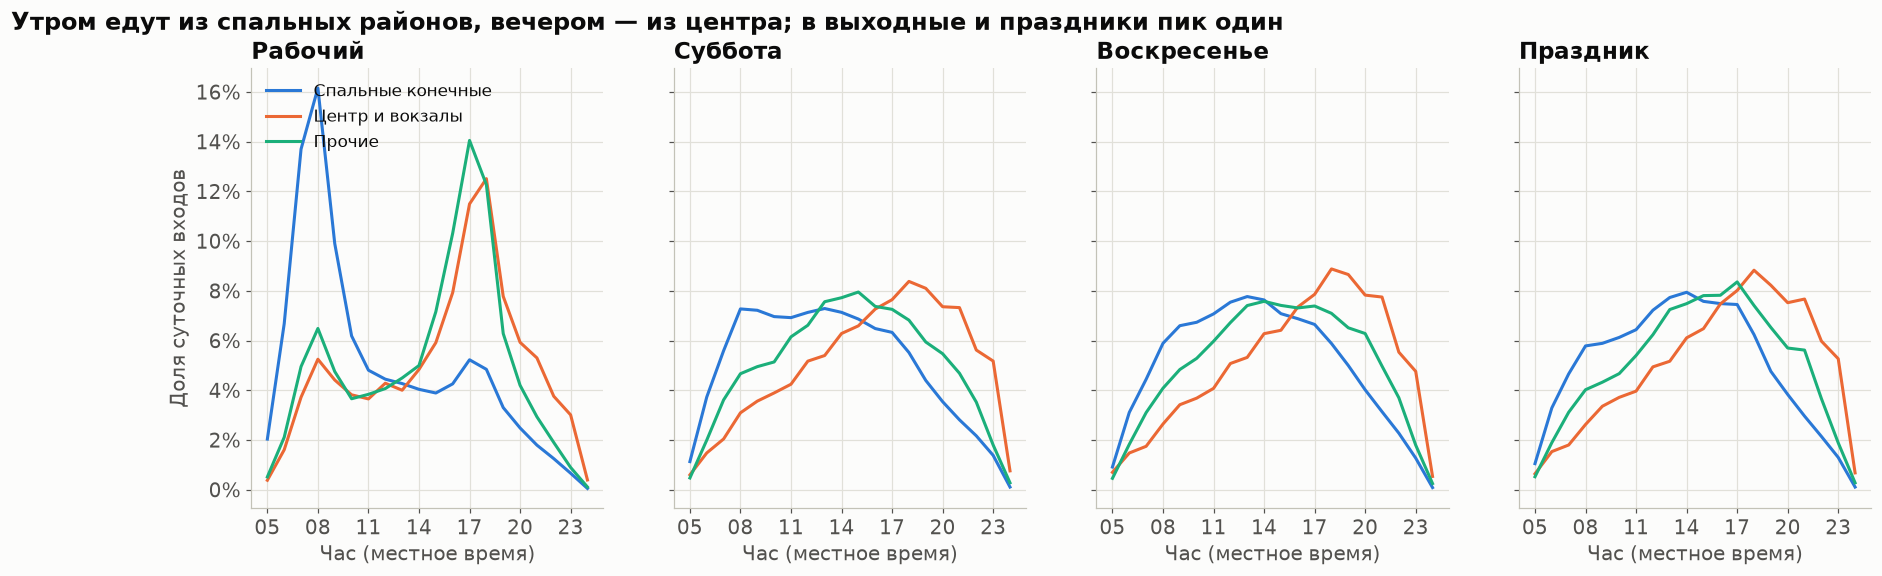

Рабочий день, утро/вечер: спальные конечные ×3,09, центр и вокзалы ×0,42, прочие ×0,46; в выходные и праздники утреннего пика нет ни у одной группы.


In [2]:
prof = E.daily_profiles(d)
fig, axes = plt.subplots(1, 4, figsize=(19, 5.2), sharey=True)
for ax, dt in zip(axes, E.DAY_TYPES):
    for grp in E.GROUPS:
        p = prof[(prof.group == grp) & (prof.day_type == dt)].set_index("hour").share.reindex(HOURS)
        ax.plot(range(len(HOURS)), p.to_numpy(), color=E.GROUP_COLORS[grp], label=grp)
    ax.set_title(dt.capitalize(), loc="left")
    hour_ticks(ax)
    ax.set_xlabel("Час (местное время)")
    ax.yaxis.set_major_formatter(PCT)
axes[0].set_ylabel("Доля суточных входов")
axes[0].legend(loc="upper left")
fig.suptitle("Утром едут из спальных районов, вечером — из центра; в выходные и праздники пик один",
             x=0.01, ha="left", fontsize=16, fontweight="bold")
eda.save(fig, "spb_01_profiles")
plt.show()

gr = E.peak_ratios(d, "group").ratio
print("Рабочий день, утро/вечер: " + ", ".join(f"{g.lower()} ×{num(gr[g], 2)}" for g in E.GROUPS)
      + "; в выходные и праздники утреннего пика нет ни у одной группы.")

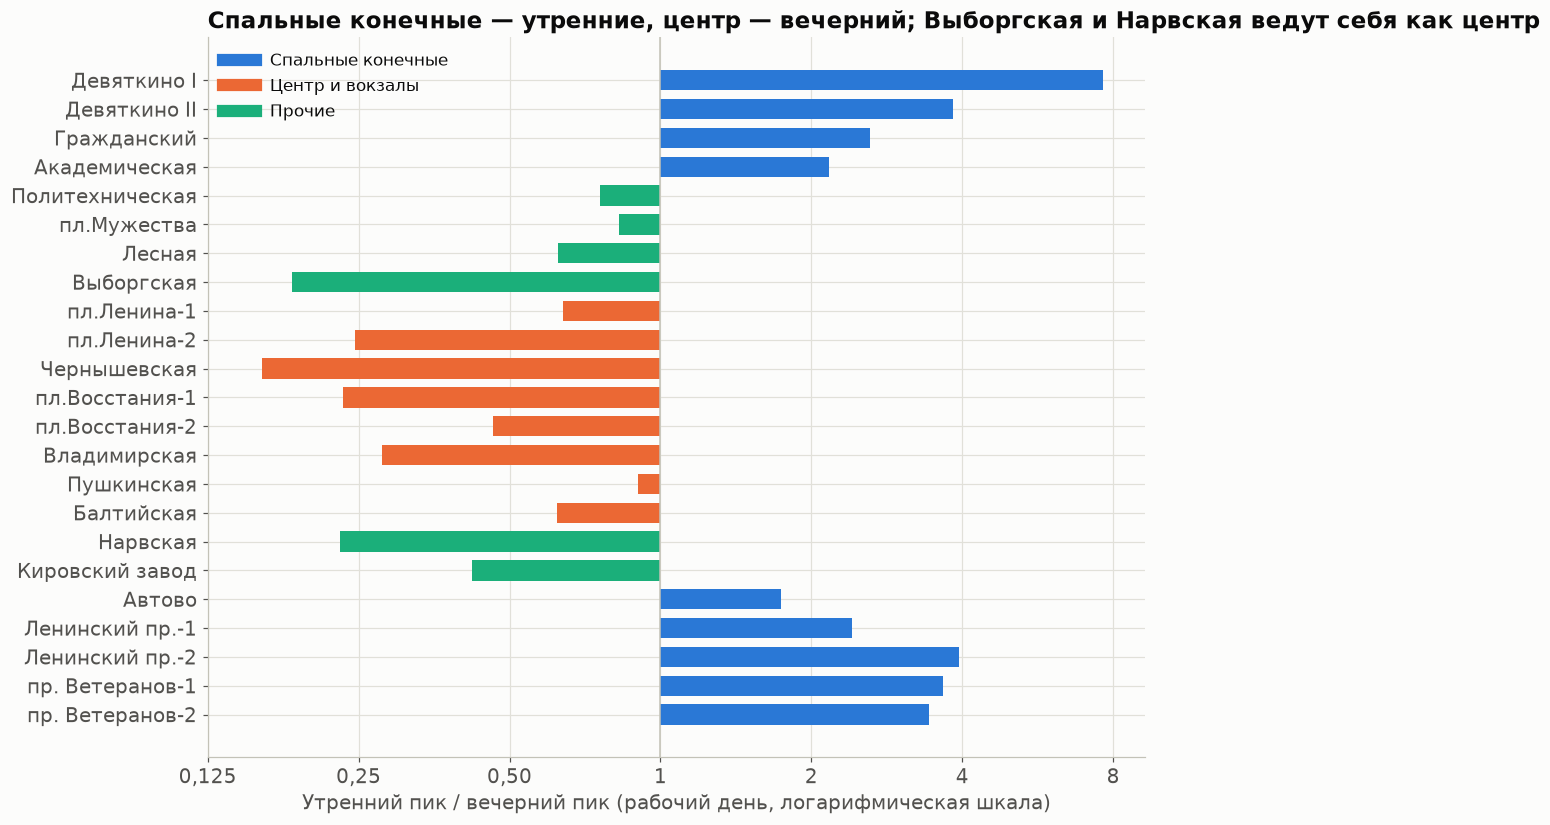

Спальные конечные: утро/вечер ×1,74…7,6 (Девяткино I ×7,6); центр и вокзалы ×0,16…0,90 (Пушкинская ×0,90 — смешанная); среди прочих «вечерние» — Выборгская ×0,18, Нарвская ×0,23.


In [3]:
pr = E.peak_ratios(d).reindex(ves.vestibule_id)
pr["name"], pr["group"] = ves.raw_name.to_numpy(), ves.group.to_numpy()
fig, ax = plt.subplots(figsize=(11, 8.5))
y = np.arange(len(pr))
ax.barh(y, np.log2(pr.ratio), height=0.7, color=[E.GROUP_COLORS[g] for g in pr.group])
ax.axvline(0, color=eda.AXIS, linewidth=1)
ax.set_yticks(y, pr.name)
ax.invert_yaxis()
ticks = [0.125, 0.25, 0.5, 1, 2, 4, 8]
ax.set_xticks(np.log2(ticks), [num(t, 3 if t < 0.2 else (2 if t < 1 else 0)) for t in ticks])
ax.set_xlabel("Утренний пик / вечерний пик (рабочий день, логарифмическая шкала)")
ax.set_title("Спальные конечные — утренние, центр — вечерний; Выборгская и Нарвская ведут себя как центр", loc="left")
ax.legend(handles=[Line2D([], [], color=E.GROUP_COLORS[g], linewidth=8, label=g) for g in E.GROUPS],
          loc="upper left")
eda.save(fig, "spb_01_peak_ratio")
plt.show()

g = pr.groupby("group").ratio
odd = pr[(pr.group == "Прочие") & (pr.ratio < 0.3)]
print(f"Спальные конечные: утро/вечер ×{num(g.min()['Спальные конечные'], 2)}…{num(g.max()['Спальные конечные'], 1)} "
      f"(Девяткино I ×{num(pr.loc['devyatkino_1', 'ratio'], 1)}); центр и вокзалы ×{num(g.min()['Центр и вокзалы'], 2)}…"
      f"{num(g.max()['Центр и вокзалы'], 2)} (Пушкинская ×{num(pr.loc['pushkinskaya_1', 'ratio'], 2)} — смешанная); "
      f"среди прочих «вечерние» — " + ", ".join(f"{n} ×{num(r, 2)}" for n, r in zip(odd.name, odd.ratio)) + ".")

## 2. Дни недели

Средние обычные рабочие сутки по дням недели относительно вт–чт (95 % ДИ — бутстреп по дням).
Отдельно — шум |r − 1| (p80, взвешено по потоку) при норме по дню недели и по типу дня («рабочий» — все будни за 28 прошлых суток).

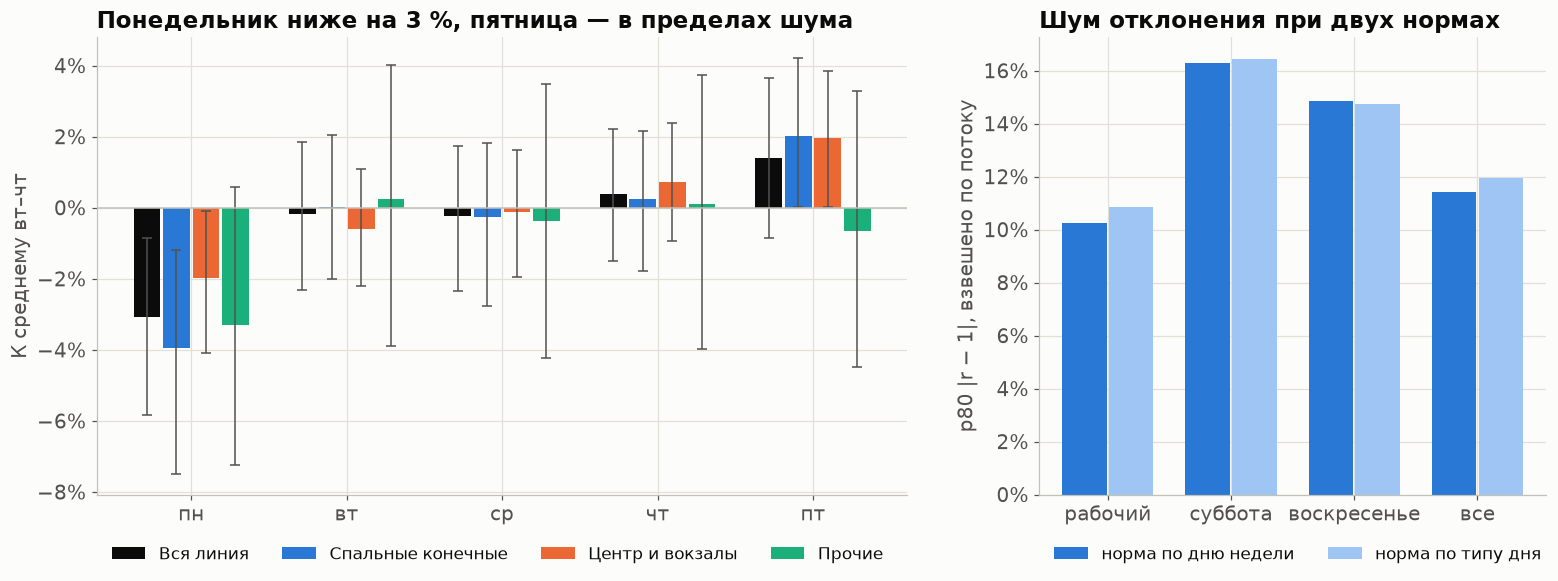

Линия к вт–чт: пн -3,1% (ДИ -5,8%…-0,8%), пт +1,4% (ДИ -0,9%…+3,6%) — в MTA было −10 %; норма по дню недели точнее: p80 будней 10,3% против 10,9%, p95 22,5% против 25,7%.


In [4]:
wl = E.weekday_levels(d)
nk = E.noise_by_key(d)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 5.4), gridspec_kw={"width_ratios": [1.6, 1]})
levels = ["Вся линия"] + E.GROUPS
w = 0.19
for i, lvl in enumerate(levels):
    s = wl[wl.level == lvl].set_index("dow")
    x = s.index + (i - 1.5) * w
    a1.bar(x, s.effect, width=w * 0.9, color=LEVEL_COLORS[lvl], label=lvl,
           yerr=[s.effect - s.lo, s.hi - s.effect], capsize=3, error_kw={"ecolor": eda.INK2, "elinewidth": 1})
a1.axhline(0, color=eda.AXIS, linewidth=1)
a1.set_xticks(range(5), DOW[:5])
a1.yaxis.set_major_formatter(PCT)
a1.set_ylabel("К среднему вт–чт")
a1.set_title("Понедельник ниже на 3 %, пятница — в пределах шума", loc="left")
a1.legend(loc="upper left", bbox_to_anchor=(0, -0.08), ncol=4)
k = nk.pivot(index="day_type", columns="key", values="p80").loc[["рабочий", "суббота", "воскресенье", "все"]]
x = np.arange(len(k))
a2.bar(x - 0.19, k["день недели"], width=0.36, color=eda.SERIES[0], label="норма по дню недели")
a2.bar(x + 0.19, k["тип дня"], width=0.36, color=eda.BLUE_RAMP[1], label="норма по типу дня")
a2.set_xticks(x, k.index)
a2.yaxis.set_major_formatter(PCT)
a2.set_ylabel("p80 |r − 1|, взвешено по потоку")
a2.set_title("Шум отклонения при двух нормах", loc="left")
a2.legend(loc="upper left", bbox_to_anchor=(0, -0.08), ncol=2)
eda.save(fig, "spb_02_weekdays")
plt.show()

ln = wl[wl.level == "Вся линия"].set_index("dow")
kw = nk.set_index(["key", "day_type"])
print(f"Линия к вт–чт: пн {pct(ln.effect[0])} (ДИ {pct(ln.lo[0])}…{pct(ln.hi[0])}), пт {pct(ln.effect[4])} "
      f"(ДИ {pct(ln.lo[4])}…{pct(ln.hi[4])}) — в MTA было −10 %; норма по дню недели точнее: p80 будней "
      f"{pp(kw.loc[('день недели', 'рабочий'), 'p80'])} против {pp(kw.loc[('тип дня', 'рабочий'), 'p80'])}, "
      f"p95 {pp(kw.loc[('день недели', 'рабочий'), 'p95'])} против {pp(kw.loc[('тип дня', 'рабочий'), 'p95'])}.")

## 3. Тренд по месяцам

Средние обычные рабочие сутки по месяцам (не зависят от длины месяца и числа выходных); группы — к своему среднему за март–май.
Ступень 01.09 — 10 обычных рабочих дней после против 10 до.

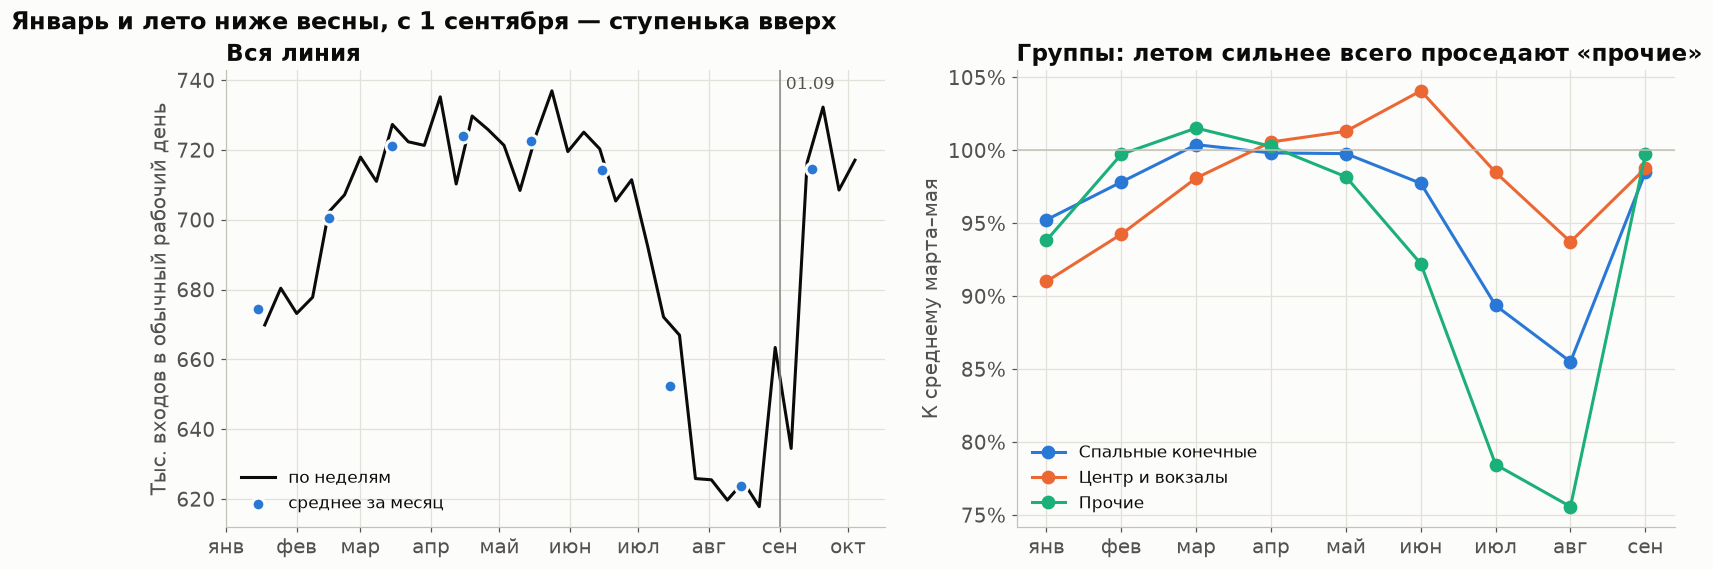

К весне (март–май, 723 тыс./сут): январь -6,7%, июнь -1,1%, июль -9,7%, август -13,7%, сентябрь -1,1%; ступень 01.09: линия +13,5%, спальные конечные +15,1%, центр и вокзалы +4,6%, прочие +28,3%.


In [5]:
mt = E.monthly_trend(d)
step = E.september_step(d).set_index("level")
wk = E.weekly_level(d)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 5.4))
line = mt[mt.level == "Вся линия"].set_index("month")
a1.plot(wk.index, wk / 1000, color=eda.INK, linewidth=2, label="по неделям")
a1.scatter([pd.Timestamp(2026, m, 15) for m in line.index], line["mean"] / 1000, s=70, color=eda.SERIES[0],
           edgecolor=eda.SURFACE, linewidth=2, zorder=3, label="среднее за месяц")
a1.axvline(pd.Timestamp("2026-09-01"), color=eda.MUTED, linewidth=1)
a1.annotate("01.09", (pd.Timestamp("2026-09-01"), a1.get_ylim()[1]), xytext=(4, -4), textcoords="offset points",
            va="top", color=eda.INK2, fontsize=11)
a1.set_xticks([pd.Timestamp(2026, m, 1) for m in range(1, 11)], MONTHS + ["окт"])
a1.set_ylabel("Тыс. входов в обычный рабочий день")
a1.set_title("Вся линия", loc="left")
a1.legend(loc="lower left")
for grp in E.GROUPS:
    g = mt[mt.level == grp].set_index("month")["mean"]
    a2.plot(g.index, g / g.loc[[3, 4, 5]].mean(), marker="o", color=E.GROUP_COLORS[grp], label=grp)
a2.axhline(1, color=eda.AXIS, linewidth=1)
a2.set_xticks(range(1, 10), MONTHS)
a2.yaxis.set_major_formatter(PCT)
a2.set_ylabel("К среднему марта–мая")
a2.set_title("Группы: летом сильнее всего проседают «прочие»", loc="left")
a2.legend(loc="lower left")
fig.suptitle("Январь и лето ниже весны, с 1 сентября — ступенька вверх", x=0.01, ha="left", fontsize=16, fontweight="bold")
eda.save(fig, "spb_03_monthly")
plt.show()

m = line["mean"]
spring = m.loc[[3, 4, 5]].mean()
print(f"К весне (март–май, {num(spring / 1000)} тыс./сут): январь {pct(m[1] / spring - 1)}, июнь {pct(m[6] / spring - 1)}, "
      f"июль {pct(m[7] / spring - 1)}, август {pct(m[8] / spring - 1)}, сентябрь {pct(m[9] / spring - 1)}; ступень 01.09: "
      f"линия {pct(step.step['Вся линия'])}, " + ", ".join(f"{g.lower()} {pct(step.step[g])}" for g in E.GROUPS) + ".")

## 4. Праздники и переносы

Сутки линии в особые дни против того же дня недели ±1 и ±2 недели (только обычные дни). Сокращённые дни — по часам.
Профиль будних праздников против обычных воскресений, суббот и рабочих дней тех же месяцев.

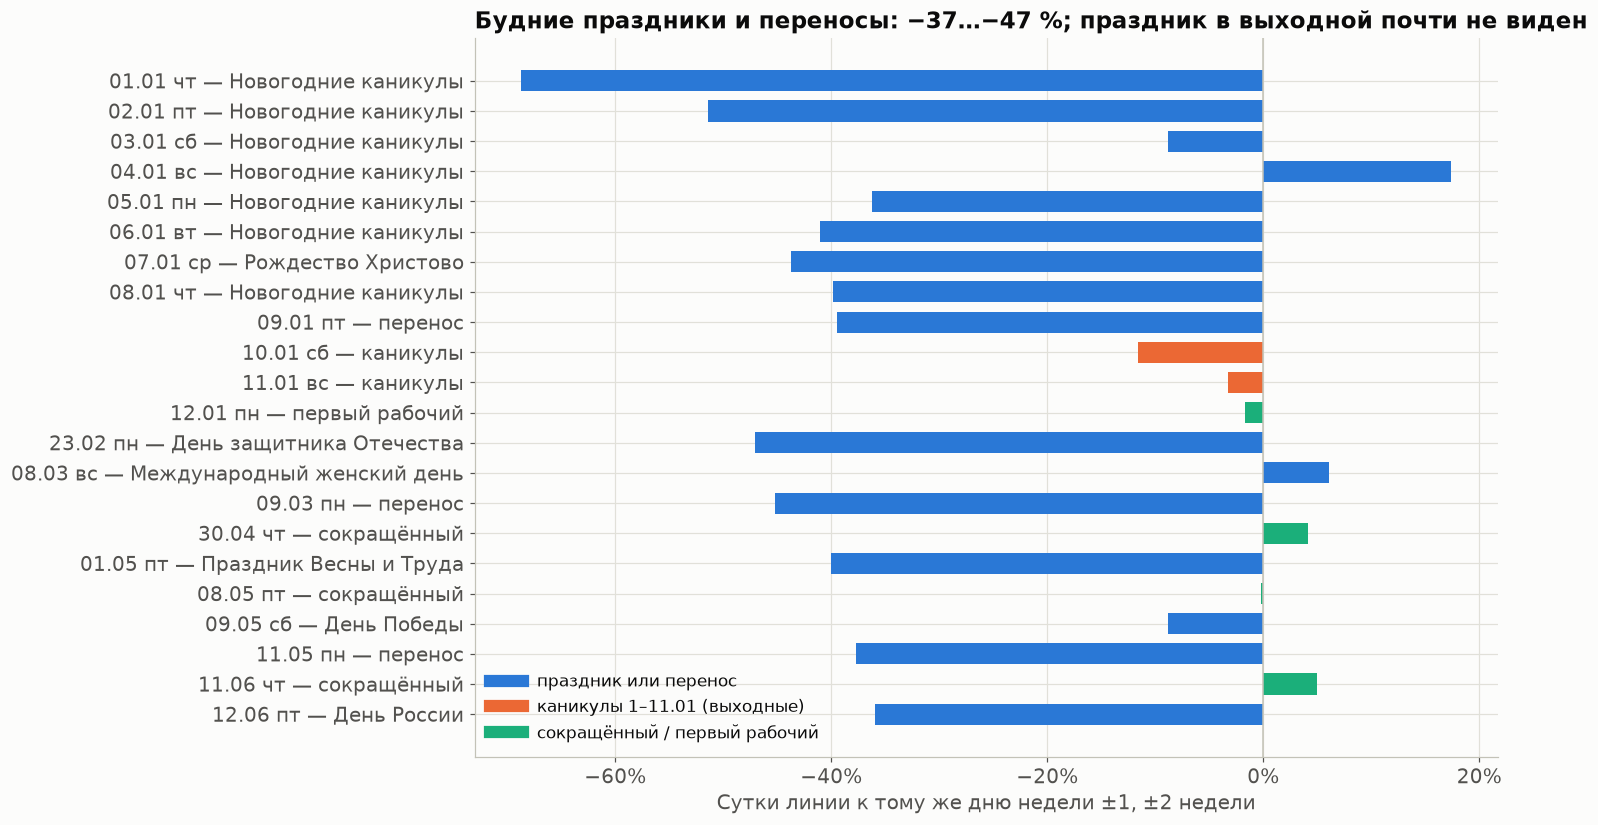

Будние праздники и переносы (кроме 1–2 января): медиана -39,9%, -47,1%…-35,9% (n = 10); 1 января -68,7%; праздник в выходной: 8 марта (вс) +6,1%, 9 мая (сб) -8,8%; первый рабочий 12.01 -1,7%; рабочих суббот в 2026 г. нет — проверить нечего.


In [6]:
he = E.holiday_effects(d)
kind_color = {"праздник": eda.SERIES[0], "перенос": eda.SERIES[0], "каникулы": eda.SERIES[1],
              "сокращённый": eda.SERIES[2], "первый рабочий": eda.SERIES[2]}
fig, ax = plt.subplots(figsize=(12, 8.5))
y = np.arange(len(he))
ax.barh(y, he.effect, height=0.7, color=[kind_color[k] for k in he.kind])
ax.axvline(0, color=eda.AXIS, linewidth=1)
labels = [f"{x:%d.%m} {DOW[x.dayofweek]} — {l}" for x, l in zip(he.date, he.label)]
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(PCT)
ax.set_xlabel("Сутки линии к тому же дню недели ±1, ±2 недели")
ax.set_title("Будние праздники и переносы: −37…−47 %; праздник в выходной почти не виден", loc="left")
ax.legend(handles=[Line2D([], [], color=c, linewidth=8, label=l) for l, c in
                   (("праздник или перенос", eda.SERIES[0]), ("каникулы 1–11.01 (выходные)", eda.SERIES[1]),
                    ("сокращённый / первый рабочий", eda.SERIES[2]))], loc="lower left")
eda.save(fig, "spb_04_holidays")
plt.show()

wk_hol = he[(he.day_type == "праздник") & (he.dow < 5) & (he.date > "2026-01-02")]
print(f"Будние праздники и переносы (кроме 1–2 января): медиана {pct(wk_hol.effect.median())}, "
      f"{pct(wk_hol.effect.min())}…{pct(wk_hol.effect.max())} (n = {len(wk_hol)}); 1 января {pct(he.effect.iloc[0])}; "
      f"праздник в выходной: 8 марта (вс) {pct(he.set_index('date').effect['2026-03-08'])}, 9 мая (сб) "
      f"{pct(he.set_index('date').effect['2026-05-09'])}; первый рабочий 12.01 {pct(he.set_index('date').effect['2026-01-12'])}; "
      f"рабочих суббот в 2026 г. нет — проверить нечего.")

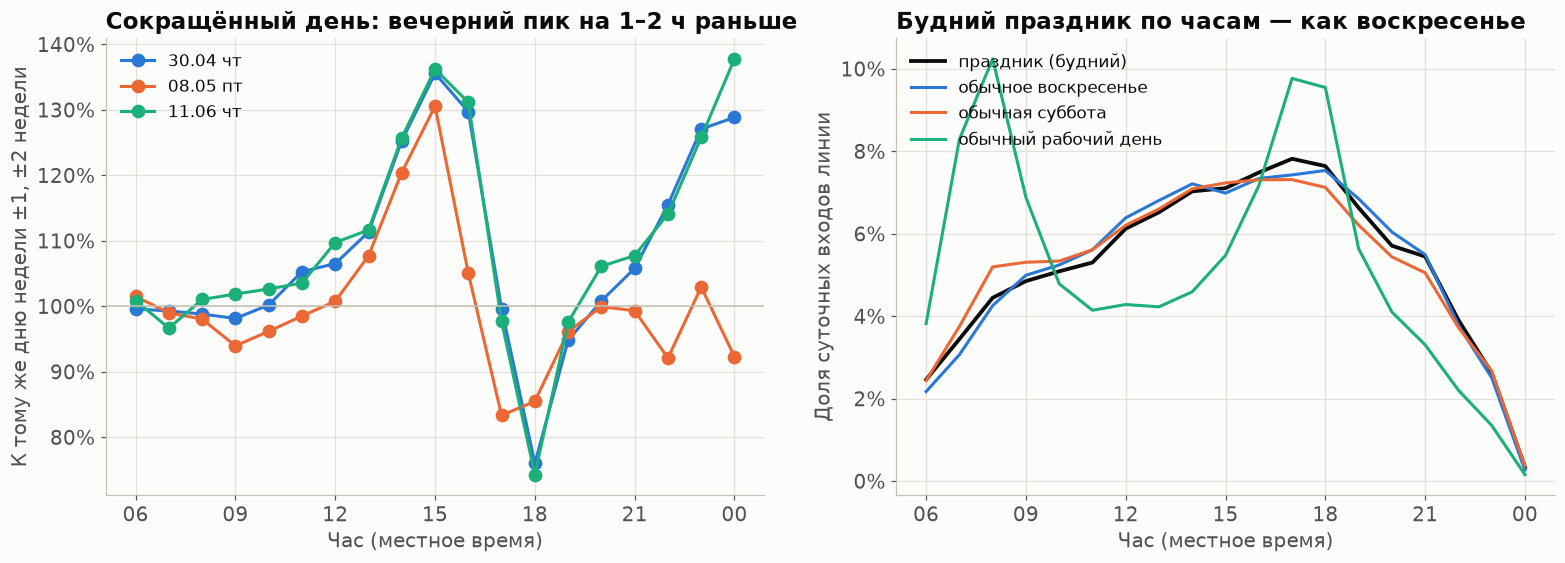

Сокращённые дни: сутки +4,2%, -0,3%, +5,0%, но 14–16 ч +26,6%, 18 ч -21,4%, 22–23 ч +12,9%; профиль будних праздников: корреляция с воскресным 0,994, с субботним 0,987, с рабочим 0,55.


In [7]:
short_days = ["2026-04-30", "2026-05-08", "2026-06-11"]
hv = pd.DataFrame({x: E.hourly_vs_base(d, pd.Timestamp(x)) for x in short_days})
hp = E.holiday_profile(d)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 5.4))
for c, x in zip(eda.SERIES, short_days):
    a1.plot([HPOS[h] for h in hv.index], hv[x], color=c, marker="o", label=f"{pd.Timestamp(x):%d.%m} {DOW[pd.Timestamp(x).dayofweek]}")
a1.axhline(1, color=eda.AXIS, linewidth=1)
hour_ticks(a1, E.WORK_HOURS)
a1.yaxis.set_major_formatter(PCT)
a1.set_ylabel("К тому же дню недели ±1, ±2 недели")
a1.set_xlabel("Час (местное время)")
a1.set_title("Сокращённый день: вечерний пик на 1–2 ч раньше", loc="left")
a1.legend(loc="upper left")
cols = {"праздник (будний)": eda.INK, "обычное воскресенье": eda.SERIES[0], "обычная суббота": eda.SERIES[1],
        "обычный рабочий день": eda.SERIES[2]}
for k, c in cols.items():
    a2.plot([HPOS[h] for h in hp.index], hp[k], color=c, linewidth=2.5 if k.startswith("праздник") else 2, label=k)
hour_ticks(a2, E.WORK_HOURS)
a2.yaxis.set_major_formatter(PCT)
a2.set_ylabel("Доля суточных входов линии")
a2.set_xlabel("Час (местное время)")
a2.set_title("Будний праздник по часам — как воскресенье", loc="left")
a2.legend(loc="upper left")
eda.save(fig, "spb_04_shortened")
plt.show()

c = hp.corr()["праздник (будний)"]
print(f"Сокращённые дни: сутки {', '.join(pct(he.set_index('date').effect[x]) for x in short_days)}, но 14–16 ч "
      f"{pct(hv.loc[[14, 15, 16]].mean().mean() - 1)}, 18 ч {pct(hv.loc[18].mean() - 1)}, 22–23 ч "
      f"{pct(hv.loc[[22, 23]].mean().mean() - 1)}; профиль будних праздников: корреляция "
      f"с воскресным {num(c['обычное воскресенье'], 3)}, с субботним {num(c['обычная суббота'], 3)}, "
      f"с рабочим {num(c['обычный рабочий день'], 2)}.")

## 5. Погода

Поток в часы с погодой против среднего опорных часов той же ячейки «вестибюль × час × тип дня × месяц» (как в MTA):
для осадков опорные — сухие часы, для мороза и жары — сухие часы с −15…+28 °C. Эффект = Σ входов / Σ нормы − 1, 95 % ДИ — бутстреп по дням.
Обычные дни, часы 06–23. Те же расчёты по историческому прогнозу — для оценки, что останется в признаках.

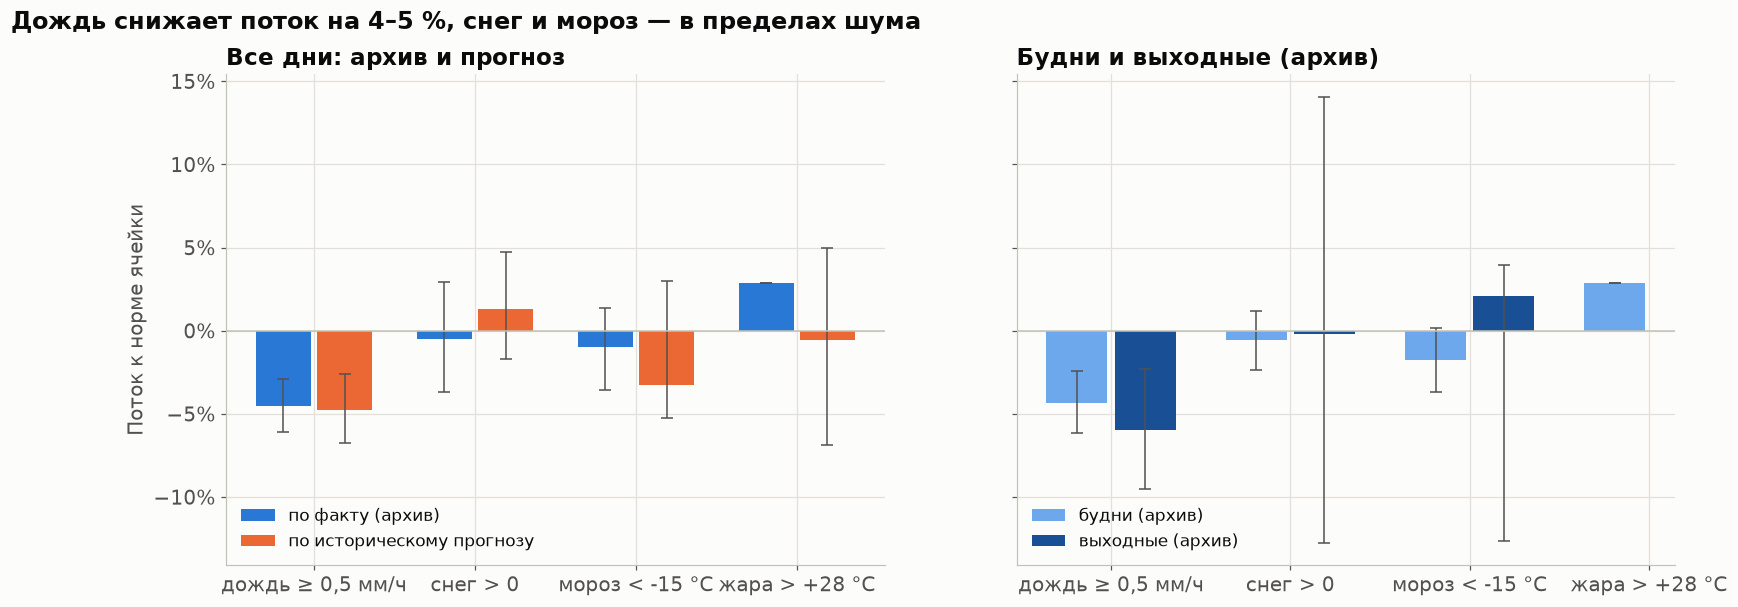

Архив: дождь -4,5% (ДИ -6,1%…-2,9%), будни -4,3%, выходные -6,0%; снег -0,5%, мороз -1,0% (ДИ -3,6%…+1,4%), жара — 1 день; по прогнозу дождь -4,8%. Прогноз дождя: precision 0,49, recall 0,45 (±1 ч — 0,62); снега: 0,66 / 0,58.


In [8]:
wa = E.weather_effects(d, d.weather)
wf = E.weather_effects(d, d.forecast)
cats = list(E.PRECIP_CATS) + list(E.TEMP_CATS)
labels = {**E.PRECIP_CATS, **E.TEMP_CATS}
x = np.arange(len(cats))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 5.8), sharey=True)
for i, (lab, df, c) in enumerate((("по факту (архив)", wa, eda.SERIES[0]), ("по историческому прогнозу", wf, eda.SERIES[1]))):
    s = df[df.segment == "все дни"].set_index("cat").reindex(cats)
    a1.bar(x + (i - 0.5) * 0.38, s.effect, width=0.34, color=c, label=lab,
           yerr=[s.effect - s.lo, s.hi - s.effect], capsize=4, error_kw={"ecolor": eda.INK2, "elinewidth": 1})
for i, (seg, c) in enumerate((("будни", eda.BLUE_RAMP[2]), ("выходные", eda.BLUE_RAMP[5]))):
    s = wa[wa.segment == seg].set_index("cat").reindex(cats)
    a2.bar(x + (i - 0.5) * 0.38, s.effect, width=0.34, color=c, label=f"{seg} (архив)",
           yerr=[s.effect - s.lo, s.hi - s.effect], capsize=4, error_kw={"ecolor": eda.INK2, "elinewidth": 1})
for ax in (a1, a2):
    ax.axhline(0, color=eda.AXIS, linewidth=1)
    ax.set_xticks(x, [labels[c] for c in cats])
    ax.yaxis.set_major_formatter(PCT)
a1.set_ylabel("Поток к норме ячейки")
a1.set_title("Все дни: архив и прогноз", loc="left")
a2.set_title("Будни и выходные (архив)", loc="left")
a1.legend(loc="lower left")
a2.legend(loc="lower left")
fig.suptitle("Дождь снижает поток на 4–5 %, снег и мороз — в пределах шума", x=0.01, ha="left", fontsize=16, fontweight="bold")
eda.save(fig, "spb_05_weather")
plt.show()

s = wa.set_index(["cat", "segment"])
f = wf.set_index(["cat", "segment"])
sk = eda.forecast_skill(d.weather, d.forecast).set_index("cat")
print(f"Архив: дождь {pct(s.effect['rain', 'все дни'])} (ДИ {pct(s.lo['rain', 'все дни'])}…{pct(s.hi['rain', 'все дни'])}), будни "
      f"{pct(s.effect['rain', 'будни'])}, выходные {pct(s.effect['rain', 'выходные'])}; снег {pct(s.effect['snow', 'все дни'])}, "
      f"мороз {pct(s.effect['frost', 'все дни'])} (ДИ {pct(s.lo['frost', 'все дни'])}…{pct(s.hi['frost', 'все дни'])}), жара — "
      f"{int(s.n_days['heat', 'все дни'])} день; по прогнозу дождь {pct(f.effect['rain', 'все дни'])}. Прогноз дождя: precision "
      f"{num(sk.precision['rain'], 2)}, recall {num(sk.recall['rain'], 2)} (±1 ч — {num(sk.recall_pm1h['rain'], 2)}); снега: "
      f"{num(sk.precision['snow'], 2)} / {num(sk.recall['snow'], 2)}.")

## 6. События

r по вестибюлям и часам в дни событий из `events_spb.csv` (норма — обычные такие же дни недели).
«Алые паруса» — сутки метро 27.06 (вечер субботы и ночь на 28.06). Особые ночи — r всей линии вечером перед ними.

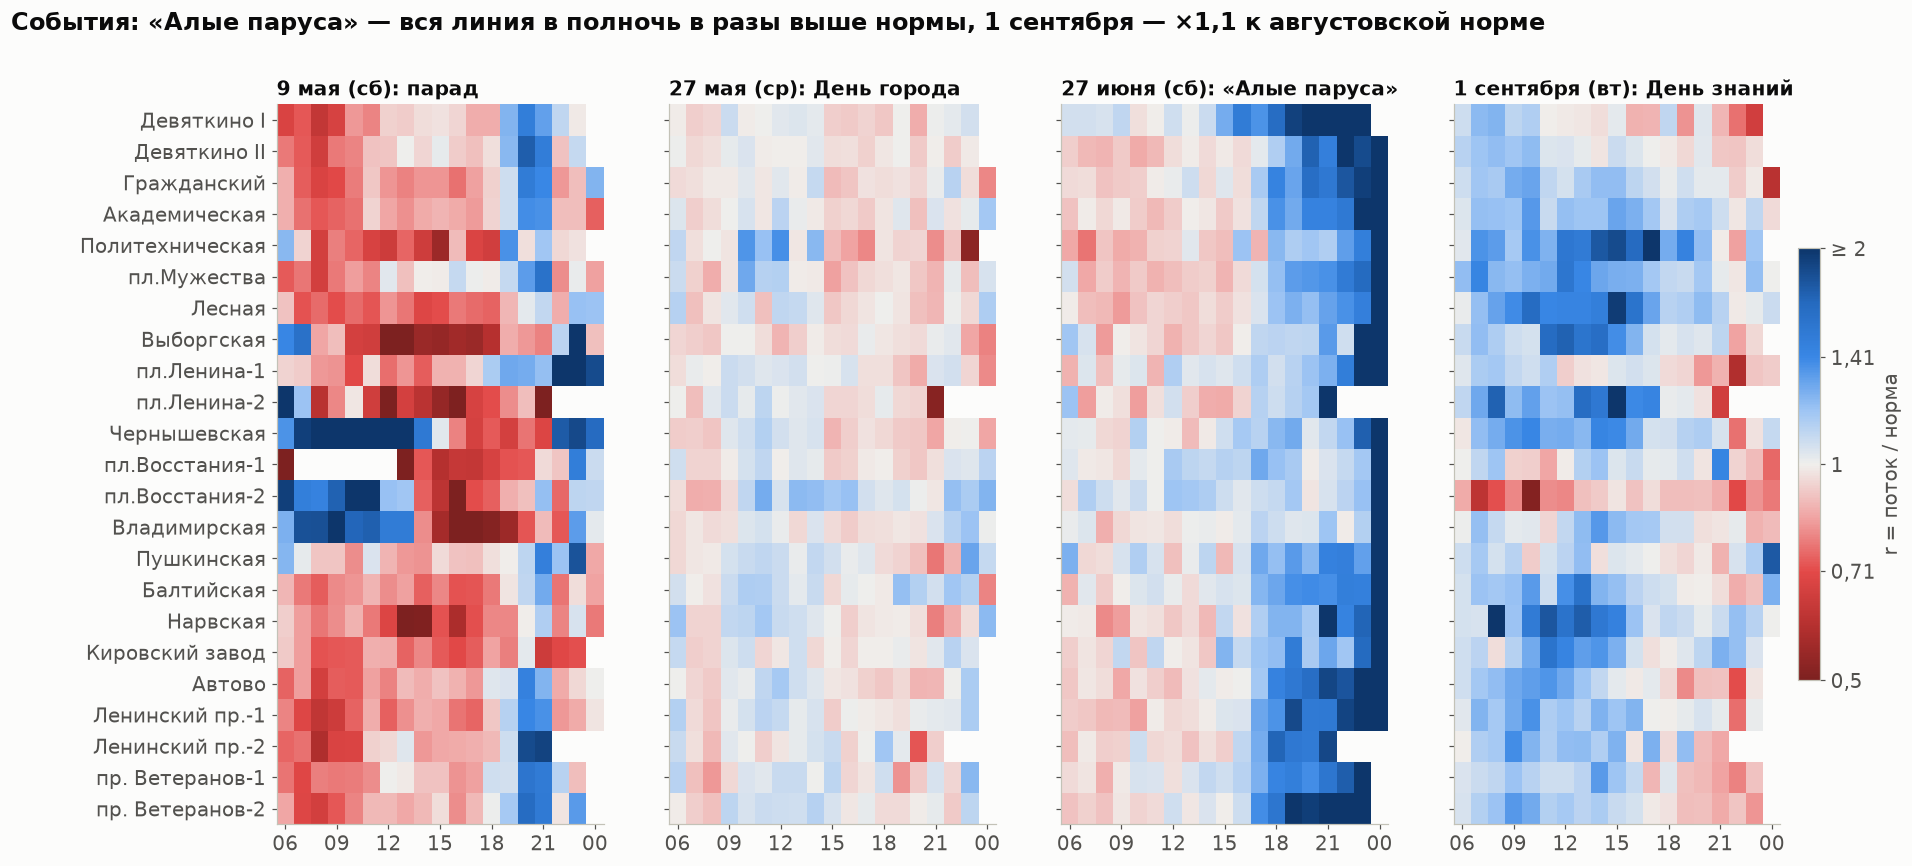

Сутки линии к норме: 9 мая 0,91 (Чернышевская 1,34), День города 0,99, «Алые паруса» 27.06 1,12, в 00 ч ×2,2…22,5, 1 сентября 1,12 (Политехническая 1,46), а к рабочим дням 2–8 сентября — 1,00: это уровень сентября, а не праздник.


In [9]:
events = [("2026-05-09", "9 мая (сб): парад"), ("2026-05-27", "27 мая (ср): День города"),
          ("2026-06-27", "27 июня (сб): «Алые паруса»"), ("2026-09-01", "1 сентября (вт): День знаний")]
LOG = lambda m: np.log2(m.clip(0.25, 4))
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
fig, axes = plt.subplots(1, 4, figsize=(21, 8.5), sharey=True)
for ax, (day, title) in zip(axes, events):
    m = E.event_matrix(d, pd.Timestamp(day))
    im = ax.imshow(LOG(m.to_numpy(dtype=float)), aspect="auto", cmap=E.diverging_cmap(), norm=norm, interpolation="nearest")
    ax.set_xticks(range(0, len(E.WORK_HOURS), 3), [f"{h:02d}" for h in E.WORK_HOURS[::3]])
    ax.set_yticks(range(len(m)), m.index)
    ax.set_title(title, loc="left", fontsize=13)
    ax.grid(False)
cb = fig.colorbar(im, ax=axes, shrink=0.6, pad=0.01)
cb.set_ticks(np.log2([0.5, 0.71, 1, 1.41, 2]), labels=["0,5", "0,71", "1", "1,41", "≥ 2"])
cb.set_label("r = поток / норма")
fig.suptitle("События: «Алые паруса» — вся линия в полночь в разы выше нормы, 1 сентября — ×1,1 к августовской норме",
             x=0.01, ha="left", fontsize=16, fontweight="bold")
eda.save(fig, "spb_06_events")
plt.show()

daily = {day: E.event_daily(d, pd.Timestamp(day)) for day, _ in events}
line_r = lambda day: (lambda x: x.y.sum() / x.b.sum())(d.df[(d.df.sday == day) & d.df.r.notna()])
sp = E.event_matrix(d, pd.Timestamp("2026-06-27"))[0]
fs = E.first_september(d)
print(f"Сутки линии к норме: 9 мая {num(line_r('2026-05-09'), 2)} (Чернышевская {num(daily['2026-05-09']['Чернышевская'], 2)}), "
      f"День города {num(line_r('2026-05-27'), 2)}, «Алые паруса» 27.06 {num(line_r('2026-06-27'), 2)}, в 00 ч ×{num(sp.min(), 1)}…{num(sp.max(), 1)}, "
      f"1 сентября {num(line_r('2026-09-01'), 2)} (Политехническая {num(fs.loc['Политехническая', 'к норме'], 2)}), а к рабочим дням "
      f"2–8 сентября — {num(fs['к 2–8 сентября'].median(), 2)}: это уровень сентября, а не праздник.")

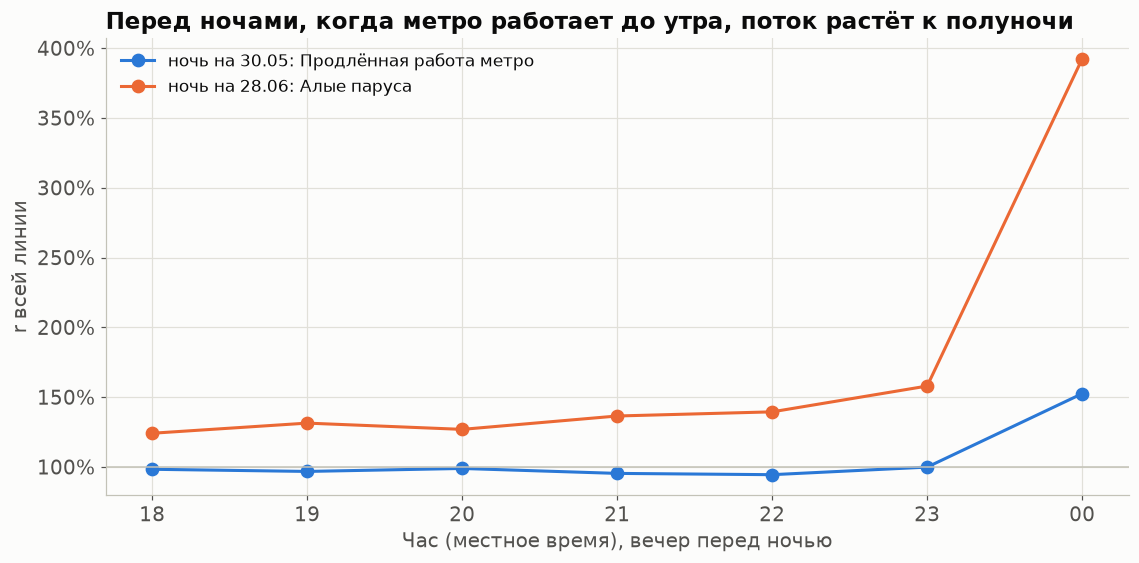

r линии в 00 ч: ночь на 30.05: Продлённая работа метро ×1,53, ночь на 28.06: Алые паруса ×3,92; вечер 18–23 ч «Алых парусов» ×1,36; январские ночи (Новый год, Рождество) без нормы — до 09.02: 2.


In [10]:
ne = E.night_evenings(d)
fig, ax = plt.subplots(figsize=(12, 5.4))
hrs = list(ne.columns)
shown = ne.dropna(how="all")
for (name, row), c in zip(shown.iterrows(), eda.SERIES + [eda.BLUE_RAMP[5]]):
    ax.plot(range(len(hrs)), row.to_numpy(), marker="o", color=c, label=name)
ax.axhline(1, color=eda.AXIS, linewidth=1)
ax.set_xticks(range(len(hrs)), [f"{h:02d}" for h in hrs])
ax.yaxis.set_major_formatter(PCT)
ax.set_xlabel("Час (местное время), вечер перед ночью")
ax.set_ylabel("r всей линии")
ax.set_title("Перед ночами, когда метро работает до утра, поток растёт к полуночи", loc="left")
ax.legend(loc="upper left")
eda.save(fig, "spb_06_nights")
plt.show()

sails = ne.loc[[n for n in ne.index if "Алые" in n][0]]
print(f"r линии в 00 ч: " + ", ".join(f"{n} ×{num(v, 2)}" for n, v in shown[0].items())
      + f"; вечер 18–23 ч «Алых парусов» ×{num(sails.loc[18:23].mean(), 2)}; "
      f"январские ночи (Новый год, Рождество) без нормы — до 09.02: {len(ne) - len(shown)}.")

## 7. Инцидент 31.08

Флаг инцидента здесь не исключаем. Доля от нормы понедельников (`r_raw`), 23 вестибюля × 06–13 ч.
Поиск похожих провалов: окно из 3 соседних станций, где Σy/Σb < 0,75, и в следующие 1–3 ч в том же окне Σy/Σb > 1,05 (откат);
тяжесть — «потерянные» входы Σb − Σy; лучший час на сутки.

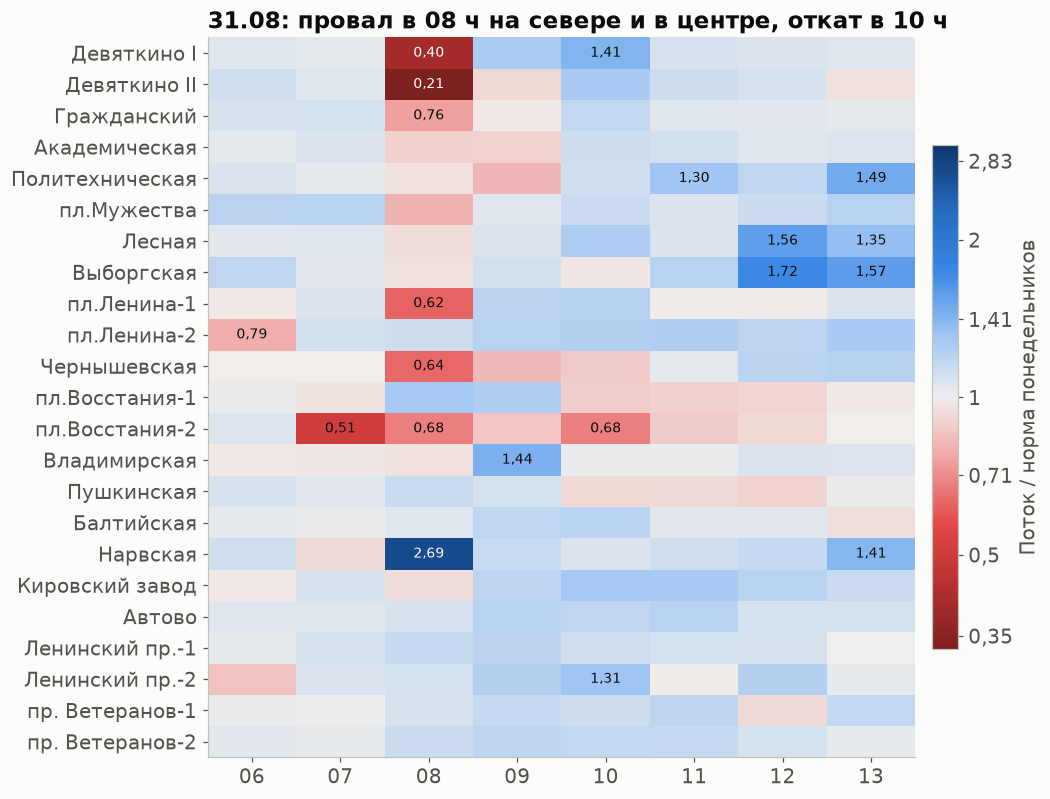

08 ч: Девяткино II 0,21, Девяткино I 0,40, пл.Ленина-1 0,62, Чернышевская 0,64, Нарвская ×2,69; 10 ч: Девяткино I ×1,41. Поиск похожих: 14 суток с провалом и откатом, из них обычных 6; 31.08 — №1 среди обычных по потерянным входам (11 542).


In [11]:
im_ = E.incident_matrix(d)
fig, ax = plt.subplots(figsize=(10, 8.5))
img = ax.imshow(np.log2(im_.to_numpy(dtype=float).clip(0.25, 4)), aspect="auto", cmap=E.diverging_cmap(),
                norm=TwoSlopeNorm(vmin=-1.6, vcenter=0, vmax=1.6), interpolation="nearest")
for (i, j), v in np.ndenumerate(im_.to_numpy(dtype=float)):
    if not np.isnan(v) and (v < 0.8 or v > 1.3):
        ax.text(j, i, num(v, 2), ha="center", va="center", fontsize=9, color="white" if (v < 0.5 or v > 2) else eda.INK)
ax.set_xticks(range(im_.shape[1]), [f"{h:02d}" for h in im_.columns])
ax.set_yticks(range(len(im_)), im_.index)
ax.grid(False)
cb = fig.colorbar(img, ax=ax, shrink=0.7, pad=0.02)
cb.set_ticks(np.log2([0.35, 0.5, 0.71, 1, 1.41, 2, 2.83]), labels=["0,35", "0,5", "0,71", "1", "1,41", "2", "2,83"])
cb.ax.set_ylim(-1.6, 1.6)
cb.set_label("Поток / норма понедельников")
ax.set_title("31.08: провал в 08 ч на севере и в центре, откат в 10 ч", loc="left")
eda.save(fig, "spb_07_incident")
plt.show()

dc = E.dip_candidates(d)
reg = dc[dc.is_regular]
rank = reg.reset_index(drop=True).index[reg.sday.reset_index(drop=True) == pd.Timestamp("2026-08-31")]
print(f"08 ч: Девяткино II {num(im_.loc['Девяткино II', 8], 2)}, Девяткино I {num(im_.loc['Девяткино I', 8], 2)}, пл.Ленина-1 "
      f"{num(im_.loc['пл.Ленина-1', 8], 2)}, Чернышевская {num(im_.loc['Чернышевская', 8], 2)}, Нарвская ×{num(im_.loc['Нарвская', 8], 2)}; "
      f"10 ч: Девяткино I ×{num(im_.loc['Девяткино I', 10], 2)}. Поиск похожих: {len(dc)} суток с провалом и откатом, из них обычных "
      f"{len(reg)}; 31.08 — №{int(rank[0]) + 1} среди обычных по потерянным входам ({num(reg.lost.iloc[int(rank[0])])}).")

In [12]:
show = dc.assign(when=dc.local.dt.strftime("%d.%m %H:00"), r_window=dc.r_window.round(2), rebound=dc.rebound.round(2),
                 lost=dc.lost.round(0).astype(int))
show[["when", "day_type", "is_regular", "stations", "r_window", "rebound", "lost"]].head(16)

,when,day_type,is_regular,stations,r_window,rebound,lost
0,09.03 18:00,праздник,False,Площадь Ленина — Чернышевская — Площадь Восстания,0.39,1.35,14991
1,31.08 08:00,рабочий,True,Девяткино — Гражданский проспект — Академическая,0.49,1.24,11542
2,23.02 09:00,праздник,False,Девяткино — Гражданский проспект — Академическая,0.33,1.05,11343
3,01.05 09:00,праздник,False,Девяткино — Гражданский проспект — Академическая,0.44,1.16,9323
4,11.05 09:00,праздник,False,Девяткино — Гражданский проспект — Академическая,0.46,1.15,9158
5,12.06 09:00,праздник,False,Девяткино — Гражданский проспект — Академическая,0.48,1.14,8809
6,11.06 18:00,рабочий,False,Площадь Ленина — Чернышевская — Площадь Восстания,0.68,1.09,7953
7,30.04 18:00,рабочий,False,Площадь Ленина — Чернышевская — Площадь Восстания,0.71,1.07,7012
8,09.05 18:00,праздник,False,Площадь Восстания — Владимирская — Пушкинская,0.70,1.08,2772
9,26.04 19:00,воскресенье,True,Выборгская — Площадь Ленина — Чернышевская,0.69,1.23,1506


## 8. Динамика отклонения

Проверка идеи признаков раздела 5: держится ли отклонение r внутри дня, предсказывает ли утро вечер и что дают простые прогнозы
`b`, `b × r(t)` и `b × сглаженное r` на t+1 и t+2 (WAPE в часах работы, где r(t) нет — прогноз b; r ограничено 0,3…3).

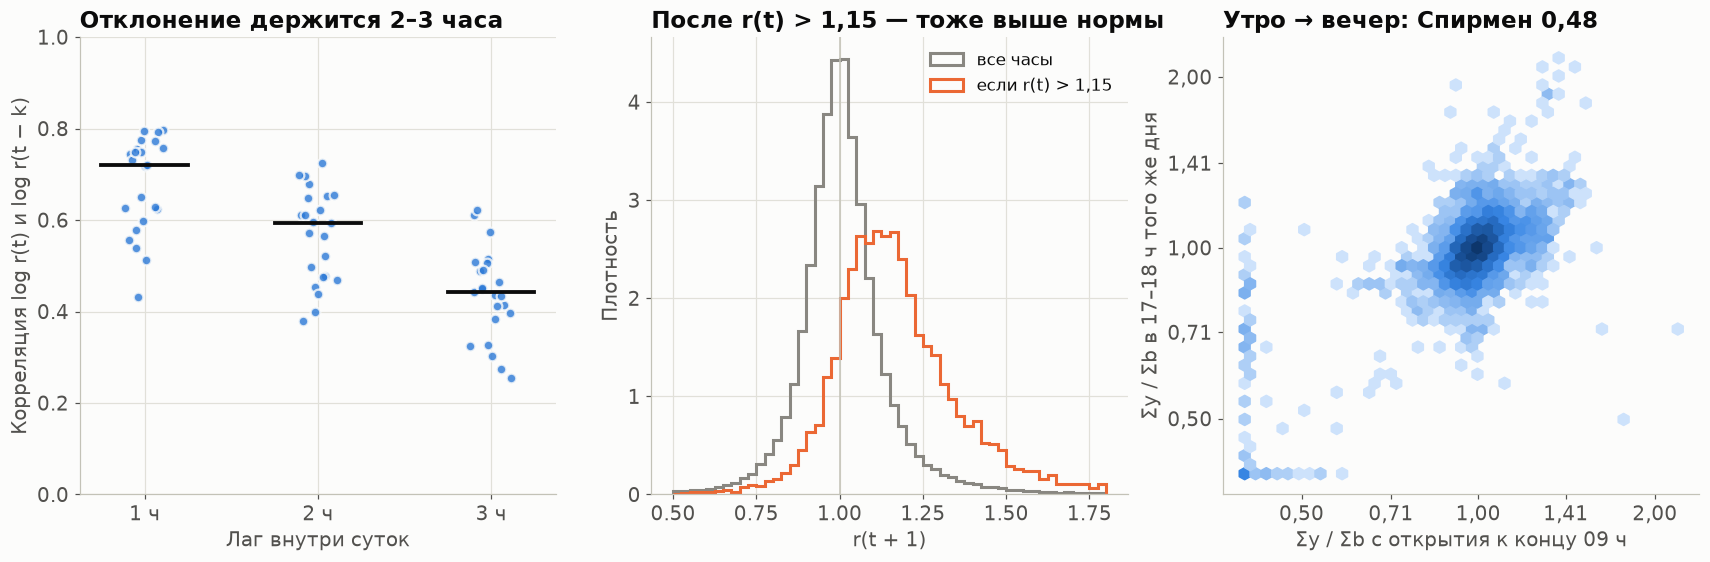

Корреляция log r с лагом 1/2/3 ч: медиана 0,72 / 0,59 / 0,44; при r(t) > 1,15 медиана r(t+1) 1,15 (без условия 1,00), выше 1,15 остаётся 50% часов (без условия 11%), на t+2 — 44%; утро → вечер: Спирмен 0,48 (n = 5 359).


In [13]:
ps = E.persistence(d)
cn = E.conditional_next(d)
mv = E.morning_vs_evening(d)
rho_mv = stats.spearmanr(mv.morning, mv.evening).statistic
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(19, 5.4))
for k in (1, 2, 3):
    v = ps[ps.lag == k].rho
    a1.scatter(np.full(len(v), k) + np.random.default_rng(k).uniform(-0.12, 0.12, len(v)), v, s=40, color=eda.SERIES[0],
               edgecolor=eda.SURFACE, linewidth=1.5, alpha=0.8)
    a1.plot([k - 0.25, k + 0.25], [v.median()] * 2, color=eda.INK, linewidth=2.5)
a1.set_xticks([1, 2, 3], ["1 ч", "2 ч", "3 ч"])
a1.set_ylim(0, 1)
a1.set_xlabel("Лаг внутри суток")
a1.set_ylabel("Корреляция log r(t) и log r(t − k)")
a1.set_title("Отклонение держится 2–3 часа", loc="left")
g = d.grid
same = (g.sday[1:] == g.sday[:-1])[:, None] & (g.sday[1:] >= E.ANALYSIS_START)[:, None]
now, nxt = g.r[:-1], g.r[1:]
m = same & ~np.isnan(now) & ~np.isnan(nxt)
bins = np.linspace(0.5, 1.8, 53)
a2.hist(nxt[m], bins=bins, density=True, histtype="step", color=eda.MUTED, linewidth=2, label="все часы")
a2.hist(nxt[m & (now > 1.15)], bins=bins, density=True, histtype="step", color=eda.SERIES[1], linewidth=2,
        label="если r(t) > 1,15")
a2.axvline(1, color=eda.AXIS, linewidth=1)
a2.set_xlabel("r(t + 1)")
a2.set_ylabel("Плотность")
a2.set_title("После r(t) > 1,15 — тоже выше нормы", loc="left")
a2.legend(loc="upper right")
hb = a3.hexbin(np.log2(mv.morning.clip(0.4, 2.5)), np.log2(mv.evening.clip(0.4, 2.5)), gridsize=40, cmap=eda.blue_cmap(),
               mincnt=1, bins="log")
t = [0.5, 0.71, 1, 1.41, 2]
a3.set_xticks(np.log2(t), [num(v, 2) for v in t])
a3.set_yticks(np.log2(t), [num(v, 2) for v in t])
a3.set_xlabel("Σy / Σb с открытия к концу 09 ч")
a3.set_ylabel("Σy / Σb в 17–18 ч того же дня")
a3.set_title(f"Утро → вечер: Спирмен {num(rho_mv, 2)}", loc="left")
a3.grid(False)
eda.save(fig, "spb_08_persistence")
plt.show()

c = cn.set_index(["h", "condition"])
med = ps.groupby("lag").rho.median()
print(f"Корреляция log r с лагом 1/2/3 ч: медиана {num(med[1], 2)} / {num(med[2], 2)} / {num(med[3], 2)}; при r(t) > 1,15 "
      f"медиана r(t+1) {num(c.p50[1, 'r(t) > 1.15'], 2)} (без условия {num(c.p50[1, 'все часы'], 2)}), выше 1,15 остаётся "
      f"{c.share_gt_thr[1, 'r(t) > 1.15']:.0%} часов (без условия {c.share_gt_thr[1, 'все часы']:.0%}), на t+2 — "
      f"{c.share_gt_thr[2, 'r(t) > 1.15']:.0%}; утро → вечер: Спирмен {num(rho_mv, 2)} (n = {num(len(mv))}).")

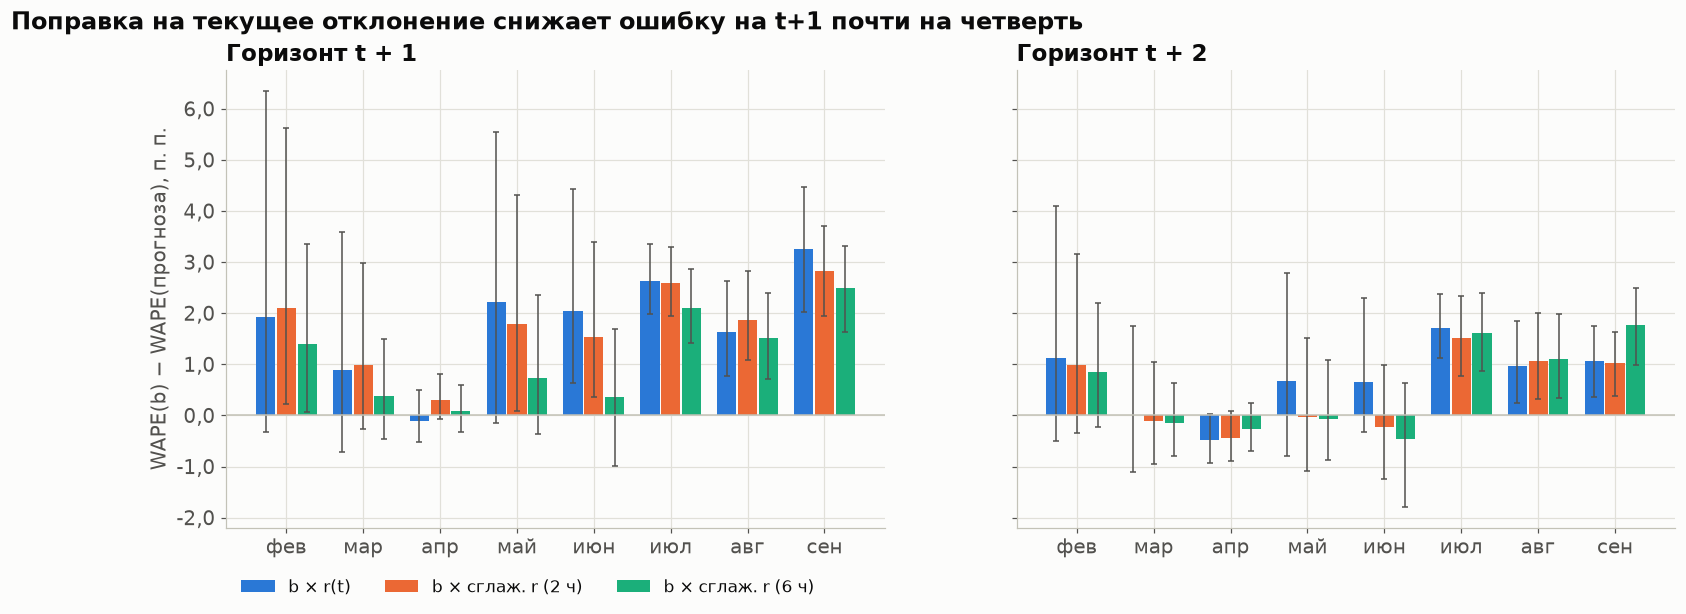

WAPE b: 8,53%; t+1: b × r(t) 6,74% (−1,79 п. п., ДИ 1,13…2,54), сглаж. 2 ч 6,81%, 6 ч 7,43%; t+2: 7,85% / 8,10% / 8,02%; в апреле выигрыша нет (-0,10 п. п., ДИ -0,53…0,50).


In [14]:
sf = E.simple_forecasts(d)
fig, axes = plt.subplots(1, 2, figsize=(17, 5.4), sharey=True)
fc = ["b × r(t)", "b × сглаж. r (2 ч)", "b × сглаж. r (6 ч)"]
for ax, h in zip(axes, (1, 2)):
    s = sf[(sf.h == h) & (sf.scope != "все месяцы")]
    for i, (f, c) in enumerate(zip(fc, eda.SERIES)):
        p = s[s.forecast == f].set_index("scope").sort_index()
        x = np.arange(len(p))
        ax.bar(x + (i - 1) * 0.27, p.dwape, width=0.25, color=c, label=f,
               yerr=[p.dwape - p.lo, p.hi - p.dwape], capsize=2, error_kw={"ecolor": eda.INK2, "elinewidth": 1})
    ax.axhline(0, color=eda.AXIS, linewidth=1)
    ax.set_xticks(x, [MONTHS[m - 1] for m in p.index])
    ax.yaxis.set_major_formatter(PPT)
    ax.set_title(f"Горизонт t + {h}", loc="left")
axes[0].set_ylabel("WAPE(b) − WAPE(прогноза), п. п.")
axes[0].legend(loc="upper left", bbox_to_anchor=(0, -0.08), ncol=3)
fig.suptitle("Поправка на текущее отклонение снижает ошибку на t+1 почти на четверть", x=0.01, ha="left",
             fontsize=16, fontweight="bold")
eda.save(fig, "spb_08_simple_forecasts")
plt.show()

a = sf[sf.scope == "все месяцы"].set_index(["h", "forecast"])
apr = sf[(sf.h == 1) & (sf.scope == 4) & (sf.forecast == "b × r(t)")].iloc[0]
print(f"WAPE b: {pp(a.wape_base[1, 'b × r(t)'], 2)}; t+1: b × r(t) {pp(a.wape_alt[1, 'b × r(t)'], 2)} "
      f"(−{ppt(a.dwape[1, 'b × r(t)'])} п. п., ДИ {ppt(a.lo[1, 'b × r(t)'])}…{ppt(a.hi[1, 'b × r(t)'])}), "
      f"сглаж. 2 ч {pp(a.wape_alt[1, 'b × сглаж. r (2 ч)'], 2)}, 6 ч {pp(a.wape_alt[1, 'b × сглаж. r (6 ч)'], 2)}; t+2: "
      f"{pp(a.wape_alt[2, 'b × r(t)'], 2)} / {pp(a.wape_alt[2, 'b × сглаж. r (2 ч)'], 2)} / "
      f"{pp(a.wape_alt[2, 'b × сглаж. r (6 ч)'], 2)}; в апреле выигрыша нет ({ppt(apr.dwape)} п. п., ДИ {ppt(apr.lo)}…{ppt(apr.hi)}).")

## 9. Синхронность

Корреляции log r по часам (обычные дни с 09.02, часы работы): между вестибюлями, в зависимости от расстояния по линии и с r всей линии.

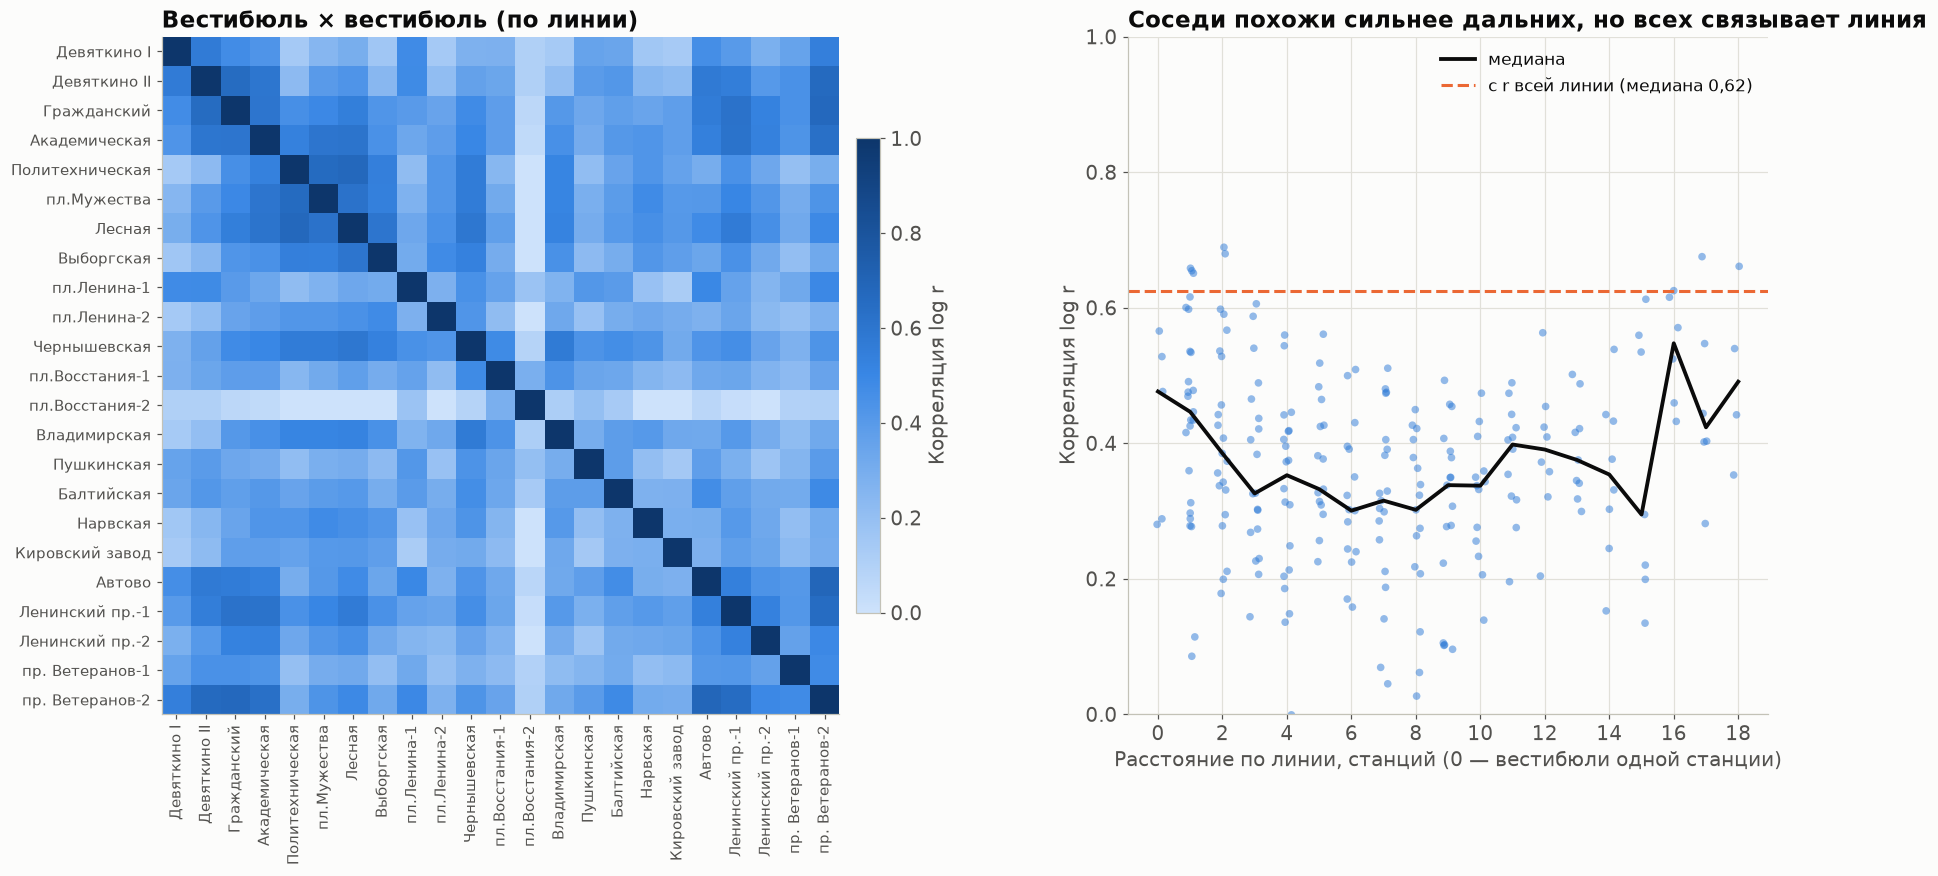

Медиана корреляции: вестибюли одной станции 0,48, соседи 0,45, через 5+ станций 0,35; с r всей линии — медиана 0,62 (пл.Восстания-2 0,30 … Чернышевская 0,75).


In [15]:
sy = E.sync(d)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(19, 8), gridspec_kw={"width_ratios": [1.3, 1]})
mtx = sy["matrix"]
img = a1.imshow(mtx.to_numpy(), cmap=eda.blue_cmap(), vmin=0, vmax=1, interpolation="nearest")
a1.set_xticks(range(len(mtx)), mtx.index, rotation=90, fontsize=10)
a1.set_yticks(range(len(mtx)), mtx.index, fontsize=10)
a1.grid(False)
fig.colorbar(img, ax=a1, shrink=0.7, pad=0.02).set_label("Корреляция log r")
a1.set_title("Вестибюль × вестибюль (по линии)", loc="left")
pairs = sy["pairs"]
med = pairs.groupby("dist")["corr"].median()
a2.scatter(pairs.dist + np.random.default_rng(0).uniform(-0.15, 0.15, len(pairs)), pairs["corr"], s=25,
           color=eda.SERIES[0], alpha=0.5, edgecolor="none")
a2.plot(med.index, med.to_numpy(), color=eda.INK, linewidth=2.5, label="медиана")
wl_ = sy["with_line"]
a2.axhline(wl_.median(), color=eda.SERIES[1], linewidth=2, linestyle="--", label=f"с r всей линии (медиана {num(wl_.median(), 2)})")
a2.set_xticks(range(0, int(pairs.dist.max()) + 1, 2))
a2.set_xlabel("Расстояние по линии, станций (0 — вестибюли одной станции)")
a2.set_ylabel("Корреляция log r")
a2.set_ylim(0, 1)
a2.set_title("Соседи похожи сильнее дальних, но всех связывает линия", loc="left")
a2.legend(loc="upper right")
eda.save(fig, "spb_09_sync")
plt.show()

print(f"Медиана корреляции: вестибюли одной станции {num(med[0], 2)}, соседи {num(med[1], 2)}, через 5+ станций "
      f"{num(pairs[pairs.dist >= 5]['corr'].median(), 2)}; с r всей линии — медиана {num(wl_.median(), 2)} "
      f"({wl_.idxmin()} {num(wl_.min(), 2)} … {wl_.idxmax()} {num(wl_.max(), 2)}).")

## 10. Шум

|r − 1| в обычные дни (с 09.02, часы работы), взвешено по потоку: p50 / p80 / p95 по группам и периодам суток.
p80 — граница «нормального» отклонения, p95 — начало аномалии.

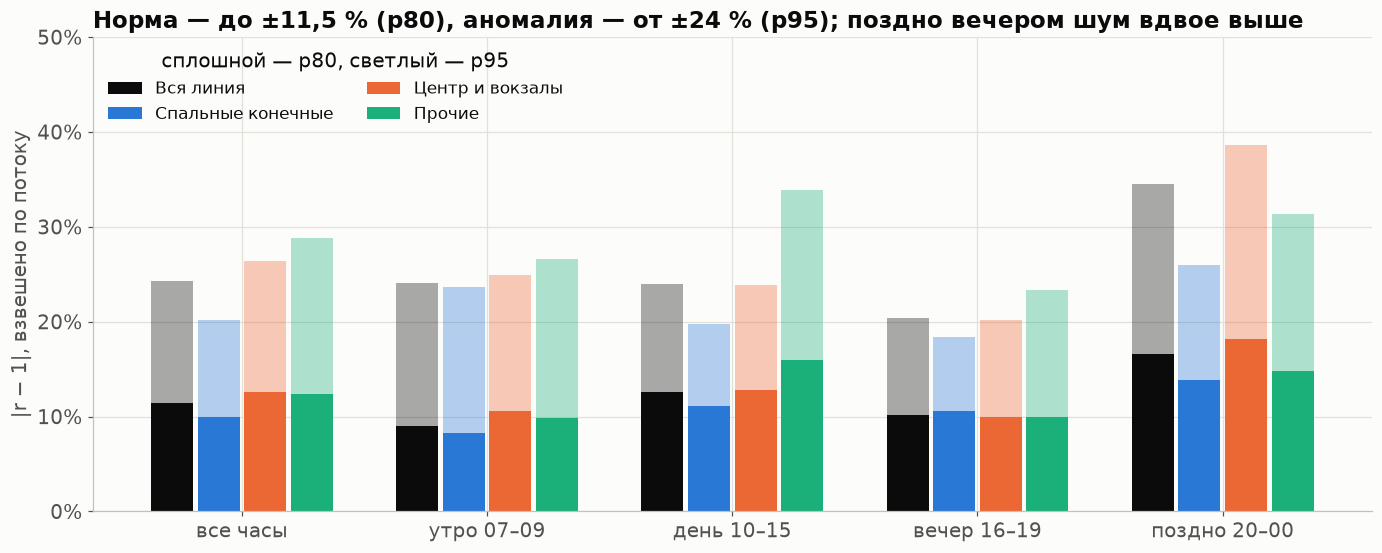

Вся линия: p50 5,0%, p80 11,4%, p95 24,2% (без взвешивания p80 13,6%); утро 07–09 p80 9,0%, поздно 20–00 — 16,6%; центр и вокзалы p95 26,4%, спальные 20,2%. MTA: p80 12 %, p95 26 %.


In [16]:
nt = E.noise_table(d)
bands = ["все часы"] + list(E.HOUR_BANDS)
levels = ["Вся линия"] + E.GROUPS
fig, ax = plt.subplots(figsize=(15, 5.6))
w = 0.19
for i, lvl in enumerate(levels):
    s = nt[nt.level == lvl].set_index("band").reindex(bands)
    x = np.arange(len(bands)) + (i - 1.5) * w
    ax.bar(x, s.p95, width=w * 0.9, color=LEVEL_COLORS[lvl], alpha=0.35)
    ax.bar(x, s.p80, width=w * 0.9, color=LEVEL_COLORS[lvl], label=lvl)
ax.set_xticks(range(len(bands)), bands)
ax.set_ylim(0, 0.5)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("|r − 1|, взвешено по потоку")
ax.set_title("Норма — до ±11,5 % (p80), аномалия — от ±24 % (p95); поздно вечером шум вдвое выше", loc="left")
ax.legend(loc="upper left", title="сплошной — p80, светлый — p95", ncol=2)
eda.save(fig, "spb_10_noise")
plt.show()

n = nt.set_index(["level", "band"])
NOISE_P80 = n.p80["Вся линия", "все часы"]
print(f"Вся линия: p50 {pp(n.p50['Вся линия', 'все часы'])}, p80 {pp(NOISE_P80)}, p95 {pp(n.p95['Вся линия', 'все часы'])} "
      f"(без взвешивания p80 {pp(n.p80_unweighted['Вся линия', 'все часы'])}); утро 07–09 p80 {pp(n.p80['Вся линия', 'утро 07–09'])}, "
      f"поздно 20–00 — {pp(n.p80['Вся линия', 'поздно 20–00'])}; центр и вокзалы p95 {pp(n.p95['Центр и вокзалы', 'все часы'])}, "
      f"спальные {pp(n.p95['Спальные конечные', 'все часы'])}. MTA: p80 12 %, p95 26 %.")

## 11. Ёмкость

Медианный вход всей линии по часам в обычные рабочие дни против провозной способности по плану: парность × 1 458 пасс. на состав
(`line1_operations.yaml`). **Оценка грубая:** в данных только входы — без пересадок, без направлений и без того,
где пассажиры выходят; нагрузка самого загруженного перегона не равна сумме входов.

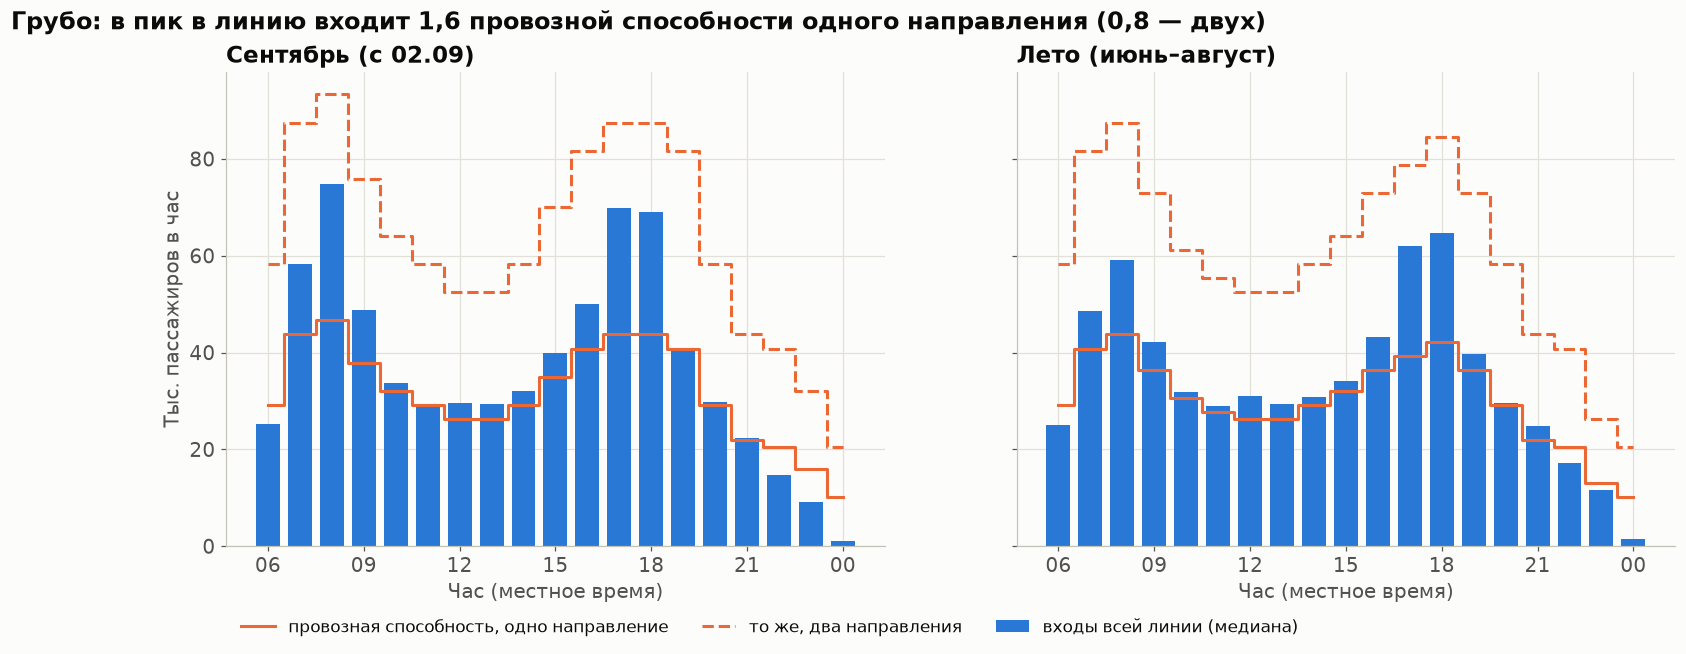

Сентябрь: пик 08 ч — 74 718 входов при 32 парах × 1 458 = 46 656 на направление (×1,60; к двум направлениям ×0,80); 17 ч ×1,60; лето — 08 ч ×1,35, 18 ч ×1,53. Только входы, без пересадок и направлений — оценка грубая.


In [17]:
cp = E.capacity(d)
fig, axes = plt.subplots(1, 2, figsize=(17, 5.6), sharey=True)
for ax, period in zip(axes, cp.period.unique()):
    s = cp[cp.period == period].set_index("hour").reindex(E.WORK_HOURS)
    x = np.arange(len(s))
    ax.bar(x, s.entries / 1000, width=0.75, color=eda.SERIES[0], label="входы всей линии (медиана)")
    ax.step(x, s.capacity / 1000, where="mid", color=eda.SERIES[1], linewidth=2, label="провозная способность, одно направление")
    ax.step(x, 2 * s.capacity / 1000, where="mid", color=eda.SERIES[1], linewidth=2, linestyle="--", label="то же, два направления")
    ax.set_xticks(x[::3], [f"{h:02d}" for h in s.index[::3]])
    ax.set_xlabel("Час (местное время)")
    ax.set_title(period.capitalize(), loc="left")
axes[0].set_ylabel("Тыс. пассажиров в час")
axes[0].legend(loc="upper left", bbox_to_anchor=(0, -0.12), ncol=3)
fig.suptitle("Грубо: в пик в линию входит 1,6 провозной способности одного направления (0,8 — двух)",
             x=0.01, ha="left", fontsize=16, fontweight="bold")
eda.save(fig, "spb_11_capacity")
plt.show()

sep = cp[cp.period.str.startswith("сентябрь")].set_index("hour")
summer = cp[cp.period.str.startswith("лето")].set_index("hour")
pk = sep.entries.idxmax()
print(f"Сентябрь: пик {pk:02d} ч — {num(sep.entries[pk])} входов при {sep.pairs[pk]} парах × 1 458 = {num(sep.capacity[pk])} "
      f"на направление (×{num(sep.load[pk], 2)}; к двум направлениям ×{num(sep.load[pk] / 2, 2)}); 17 ч ×{num(sep.load[17], 2)}; "
      f"лето — 08 ч ×{num(summer.load[8], 2)}, 18 ч ×{num(summer.load[18], 2)}. Только входы, без пересадок и направлений — оценка грубая.")

## 12. Кандидаты в признаки и их отбор

Цель — отклонение `log((y(t+h) + 1) / (b(t+h) + 1))`, h = 1 и 2; строки — часы работы без флагов с 09.02, b ≥ 20.
Кандидаты — только по данным до конца часа t (тест на утечку — `tests/test_eda_spb.py`); погода — исторический прогноз на t+h.

- **Эффект** считается внутри слота «вестибюль × час»: кандидат ранжируется, цель центрируется медианой слота — сравниваются дни
  для одного вестибюля и часа. Числовые — Спирмен и «размах» (медиана цели в верхней пятой кандидата против нижней, %),
  бинарные — разница медиан (%).
- **95 % ДИ** — блочный бутстреп по дням (1 000); **p** — 1 000 перестановок целых дней внутри месяца × «рабочий / нерабочий»,
  относительно центра нулевого распределения (`null_mean` — связь на уровне месяца); **BH** — по всем кандидатам обоих горизонтов.
- **Стабильность** — знак эффекта как у общего в ≥ 75 % месяцев (нужно ≥ 4 месяца с данными); **дубли** — Спирмен > 0,95.
- **Польза** для 15 лучших на горизонт: прогноз b · e^поправка против b, поправка — медиана цели в децили кандидата по прошлым
  месяцам минус их общая медиана; тест апрель–сентябрь; ΔWAPE с ДИ парным бутстрепом по дням, p — Диболд–Мариано (HAC, лаг 7).
- **Вердикт:** эффект меньше шума слота (p80 из п. 10) — «отбросить», даже при малом p.

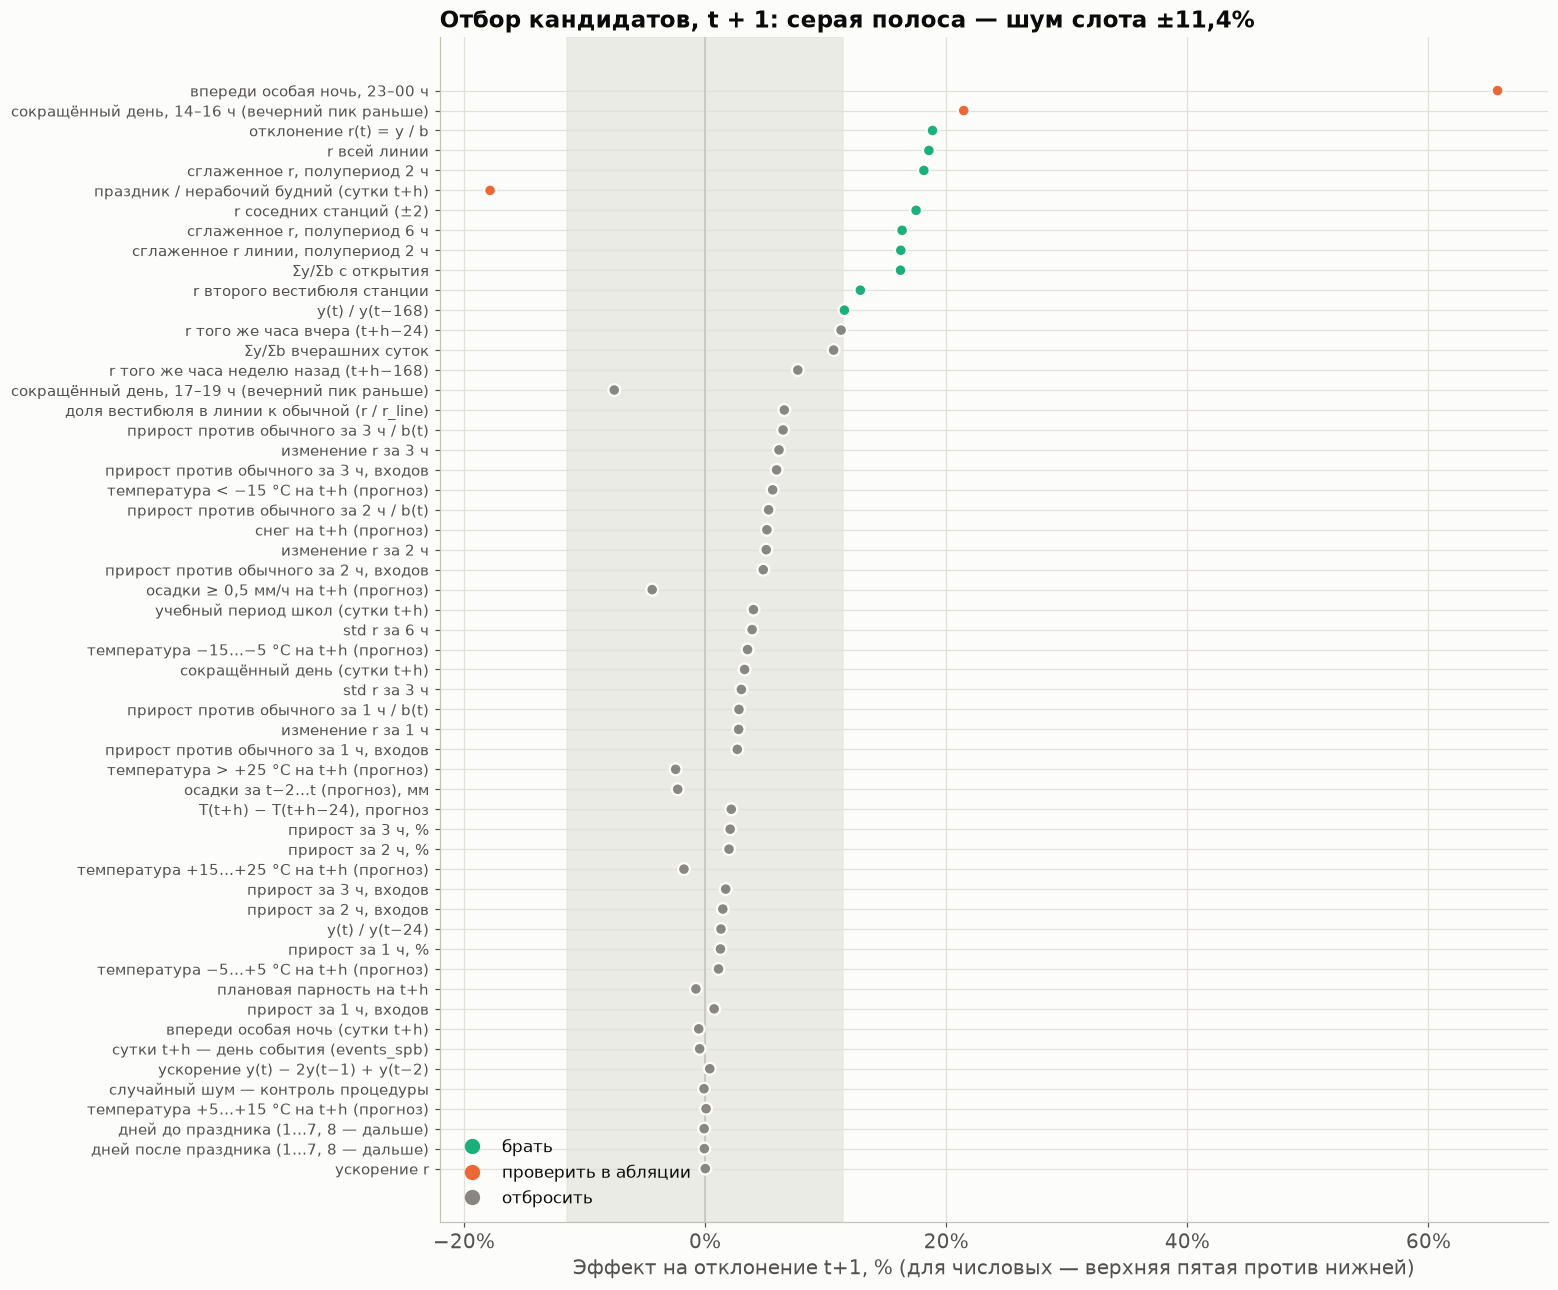

Кандидатов 56 × 2 горизонта: t+1 — брать 9, проверить 3, отбросить 44; t+2 — 8 / 3 / 45; значимых после BH, но меньше шума: 56; контрольный шум: p_BH 0,63…0,99. Таблица — data/features_screening.csv.


In [18]:
scr = E.screen(d)
gain = E.forecast_gain(d, scr)
res = E.verdict(scr, gain, NOISE_P80)
out = E.save_screening(res)
v1 = res[res.h == 1].copy()
order = v1.reindex(v1.effect_pct.abs().sort_values().index)
order = order[order.effect_pct.notna()]
vcol = {"брать": eda.SERIES[2], "проверить в абляции": eda.SERIES[1], "отбросить": eda.MUTED}
fig, ax = plt.subplots(figsize=(13, 14))
y = np.arange(len(order))
ax.axvspan(-NOISE_P80, NOISE_P80, color=eda.GRID, alpha=0.6, zorder=0)
ax.scatter(order.effect_pct, y, s=60, c=[vcol[v] for v in order.verdict], edgecolor=eda.SURFACE, linewidth=1.5, zorder=3)
ax.set_yticks(y, order.description, fontsize=10)
ax.axvline(0, color=eda.AXIS, linewidth=1)
ax.xaxis.set_major_formatter(PCT)
ax.set_xlabel("Эффект на отклонение t+1, % (для числовых — верхняя пятая против нижней)")
ax.set_title(f"Отбор кандидатов, t + 1: серая полоса — шум слота ±{pp(NOISE_P80)}", loc="left")
ax.legend(handles=[Line2D([], [], marker="o", linestyle="", color=c, markersize=9, label=k) for k, c in vcol.items()],
          loc="lower left")
eda.save(fig, "spb_12_screening")
plt.show()

cnt = res.groupby(["h", "verdict"]).size().unstack(fill_value=0)
ctrl = res[res.candidate == "noise_control"]
print(f"Кандидатов {res.candidate.nunique()} × 2 горизонта: t+1 — брать {cnt.loc[1, 'брать']}, проверить {cnt.loc[1, 'проверить в абляции']}, "
      f"отбросить {cnt.loc[1, 'отбросить']}; t+2 — {cnt.loc[2, 'брать']} / {cnt.loc[2, 'проверить в абляции']} / {cnt.loc[2, 'отбросить']}; "
      f"значимых после BH, но меньше шума: {((res.p_bh < 0.05) & (res.effect_pct.abs() < NOISE_P80) & (res.duplicate_of == '')).sum()}; "
      f"контрольный шум: p_BH {num(ctrl.p_bh.min(), 2)}…{num(ctrl.p_bh.max(), 2)}. Таблица — data/features_screening.csv.")

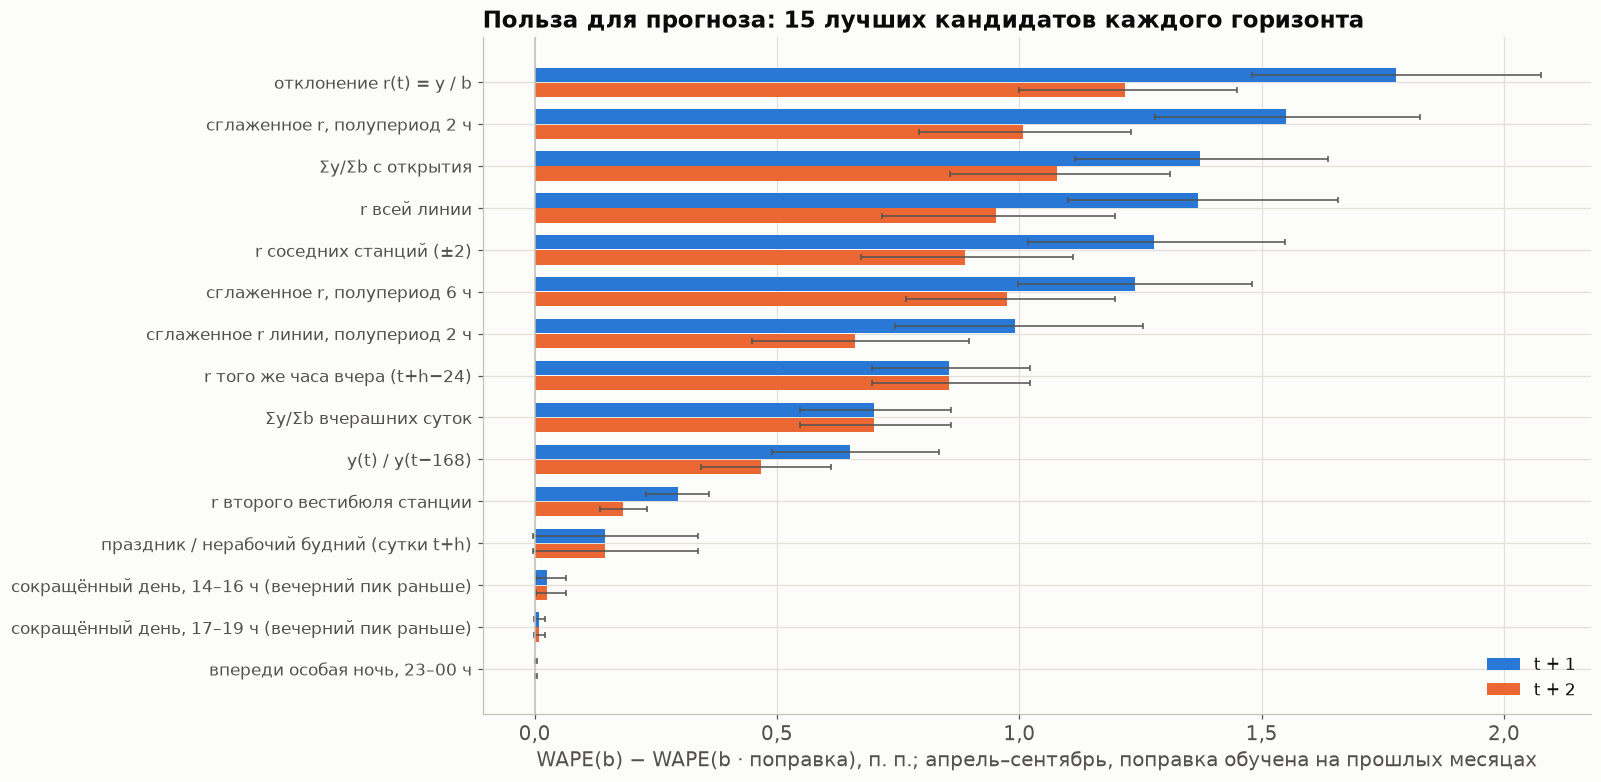

Лучшие на t+1: r −1,78 п. п., ewm_r_2h −1,55 п. п., cum_ratio −1,37 п. п., r_line −1,37 п. п. (WAPE b 8,75%); на t+2 выигрыш тех же кандидатов в 1,4 раза меньше; праздник 0,15 п. п. — всего 4 праздника в тестовых месяцах.


In [19]:
g2 = gain.merge(res[["candidate", "h", "description"]], on=["candidate", "h"])
s1 = g2[g2.h == 1].sort_values("dwape")
pos = {c: i for i, c in enumerate(s1.candidate)}
fig, ax = plt.subplots(figsize=(13, 8))
for i, (h, c) in enumerate(((1, eda.SERIES[0]), (2, eda.SERIES[1]))):
    s = g2[(g2.h == h) & g2.candidate.isin(pos)]
    yy = s.candidate.map(pos).to_numpy() + (0.5 - i) * 0.36
    ax.barh(yy, s.dwape, height=0.34, color=c, label=f"t + {h}",
            xerr=[s.dwape - s.dwape_lo, s.dwape_hi - s.dwape], capsize=2, error_kw={"ecolor": eda.INK2, "elinewidth": 1})
ax.set_yticks(np.arange(len(s1)), s1.description, fontsize=11)
ax.axvline(0, color=eda.AXIS, linewidth=1)
ax.xaxis.set_major_formatter(PPT)
ax.set_xlabel("WAPE(b) − WAPE(b · поправка), п. п.; апрель–сентябрь, поправка обучена на прошлых месяцах")
ax.set_title("Польза для прогноза: 15 лучших кандидатов каждого горизонта", loc="left")
ax.legend(loc="lower right")
eda.save(fig, "spb_12_gain")
plt.show()

take = res[(res.verdict == "брать") & (res.h == 1)].sort_values("dwape", ascending=False)
both = res[res.verdict == "брать"].pivot_table(index="candidate", columns="h", values="dwape").dropna()
print(f"Лучшие на t+1: " + ", ".join(f"{c} −{ppt(w)} п. п." for c, w in zip(take.candidate.head(4), take.dwape.head(4)))
      + f" (WAPE b {pp(gain.wape_b.iloc[0], 2)}); на t+2 выигрыш тех же кандидатов в {num((both[1] / both[2]).median(), 1)} раза меньше; праздник "
      f"{ppt(res[(res.candidate == 'is_holiday') & (res.h == 1)].dwape.iloc[0])} п. п. — всего 4 праздника в тестовых месяцах.")

In [20]:
cols = ["candidate", "group", "h", "effect", "lo", "hi", "null_mean", "effect_pct", "p_bh", "stable", "duplicate_of",
        "dwape", "verdict", "reason"]
res[res.verdict != "отбросить"][cols].round(3).sort_values(["h", "verdict", "dwape"], ascending=[True, True, False])

,candidate,group,h,effect,lo,hi,null_mean,effect_pct,p_bh,stable,duplicate_of,dwape,verdict,reason
13,r,динамика,1,0.561,0.527,0.587,0.235,0.189,0.001,1.0,,0.018,брать,"значим, стабилен, ΔWAPE +1,78 п. п. (ДИ выше н..."
18,ewm_r_2h,динамика,1,0.543,0.513,0.568,0.232,0.181,0.001,1.0,,0.015,брать,"значим, стабилен, ΔWAPE +1,55 п. п. (ДИ выше н..."
20,cum_ratio,динамика,1,0.485,0.451,0.515,0.220,0.162,0.001,1.0,,0.014,брать,"значим, стабилен, ΔWAPE +1,37 п. п. (ДИ выше н..."
25,r_line,кросс,1,0.561,0.529,0.588,0.230,0.186,0.001,1.0,,0.014,брать,"значим, стабилен, ΔWAPE +1,37 п. п. (ДИ выше н..."
26,r_neighbors,кросс,1,0.530,0.497,0.558,0.216,0.175,0.001,1.0,,0.013,брать,"значим, стабилен, ΔWAPE +1,28 п. п. (ДИ выше н..."
19,ewm_r_6h,динамика,1,0.503,0.470,0.532,0.223,0.163,0.001,1.0,,0.012,брать,"значим, стабилен, ΔWAPE +1,24 п. п. (ДИ выше н..."
49,ewm_r_line_2h,свои,1,0.493,0.457,0.523,0.199,0.162,0.001,1.0,,0.010,брать,"значим, стабилен, ΔWAPE +0,99 п. п. (ДИ выше н..."
24,ratio_168,динамика,1,0.366,0.325,0.405,0.088,0.116,0.001,1.0,,0.007,брать,"значим, стабилен, ΔWAPE +0,65 п. п. (ДИ выше н..."
27,r_twin,кросс,1,0.408,0.375,0.436,0.158,0.129,0.001,1.0,,0.003,брать,"значим, стабилен, ΔWAPE +0,30 п. п. (ДИ выше н..."
40,is_holiday,календарь,1,-0.196,-0.344,-0.030,0.012,-0.178,0.001,NaN,,0.001,проверить в абляции,"значим и ≥ шума, стабильность не проверить: вс..."
